# Post-Stroke Gait: Exploratory Data Mining Across Seven Datasets

This notebook implements the manuscript's Section 3.8 protocol and is
organized around its three research questions (RQ3 and RQ4 were merged into
one RQ3 in the manuscript on 2026-07-23, since "how classifiers performed"
was never separable in practice from "on what datasets"), so its findings
map directly onto the paper's Results/Discussion (Sections 4-5):

- **RQ1** (Part 1): which gait features discriminate healthy from post-stroke
  gait, and do useful patterns also surface across demographic groups (age,
  sex, activity level) rather than only the healthy/stroke label itself?
- **RQ2** (Part 2): which sensor placement best captures those signals?
- **RQ3** (Parts 3-4, and the datasets table below): which datasets, data
  mining, and classification methods have been used to classify and
  validate post-stroke gait, and how well do they perform? This notebook's
  own strand answers the datasets and feature-engineering half directly --
  Part 3 is literature-informed feature engineering and signal-to-noise
  ranking, Part 4 is cross-dataset validation against a pooled 335-person
  healthy reference. Classifier *performance* itself is appraised from the
  included literature (manuscript Section 4.1.3) rather than retrained here,
  a deliberate scope decision recorded in manuscript Section 3.8.

The approach throughout is **EDA before any classification claim**: every
trend is checked for confounds and cross-dataset agreement before it is
treated as discriminative. No classifier is trained anywhere in this
notebook, consistent with the manuscript's own scope decision.

## The seven datasets

Every dataset named in the manuscript is addressed here, **each per its own
composition** -- a dataset with no stroke cohort is not forced through a
stroke-classification pipeline, and a dataset with no *labeled classification
task relevant to this review's RQs* is not forced into one either (see Part 4
for which of the five non-stroke datasets got a real pipeline-generalization
check, and which -- OxWalk -- did not, and why).

### 1. Voisard et al. (2025) -- primary dataset

- **Composition**: 260 participants across `healthy` (73 HS), `neuro` (49
  CVA/stroke, 19 CIPN, 24 Parkinson's, 51 RIL), and `ortho` (44 across
  ACL/HOA/KOA) cohorts. Four IMUs per trial (head, lower back, left foot,
  right foot) at 100 Hz, plus a processed multi-sensor file, a rich metadata
  JSON (age, gender, Fugl-Meyer/TUG/visual gait scores, pre-labeled
  left/right gait events), and a plot PNG -- seven files per trial.
- **Audience/community**: clinical gait-analysis and rehabilitation
  engineering researchers; published in *Scientific Data*, aimed at reuse
  for exactly this kind of automated classification work.
- **Used here as**: the primary real stroke-vs-healthy dataset -- full EDA
  (Part 1), placement comparison (Part 2, via its four sensors), and the
  main classifier benchmark (Part 3).

### 2. Felius et al. (2024) -- second real stroke dataset

- **Composition**: real stroke patients (`Data_Stroke`) and healthy controls
  (`Data_Healthy`) from the same collection protocol, plus a longitudinal
  `Data_long` subset (repeated T0/T1 timepoints). Three IMUs per trial
  (bilateral foot + lower back, ~100 Hz, inferred from the authors' own
  filter defaults -- not stated directly in the repository). No pre-labeled
  gait events and no participant age/demographics file locally.
- **Audience/community**: biomechanics/machine-learning researchers working
  on unsupervised representation learning (variational autoencoders) for
  gait; published in *PLOS ONE*.
- **Used here as**: a second, independent real dataset -- different
  placement, different protocol, different signal-processing requirements
  (autocorrelation-based stride detection instead of labeled events) --
  used as a cross-check on Voisard's findings (Parts 1-3), not pooled with it.

### 3. GaitMotion (Zhang et al., 2024) -- simulated pathology, kept separate

- **Composition**: 10 healthy volunteers (avg age 24.8) performing three
  *simulated* gait styles: Normal, Parkinsonian ("Shuffle"), and stroke
  ("Stroke") -- confirmed against the published paper (arXiv:2405.09569).
  Not real patients.
- **Audience/community**: human-activity-recognition / deep-learning
  researchers building gait-forecasting models from ground-truth-labeled
  strides, not a clinical population study.
- **Used here as**: a separate, clearly labeled descriptive summary, plus a
  simulated-pathology classification pipeline-generalization check (Part 4,
  added 2026-07-22) using its raw IMU signal -- never pooled with the real
  Voisard/Felius stroke evidence, and never treated as real stroke evidence
  itself.

### 4. DUO-GAIT (Zhou et al., 2023) -- healthy reference, richest demographics

- **Composition**: 16 healthy adults, 9 Physilog IMUs (head, chest, sacrum,
  both wrists, both shanks, both feet) at 128 Hz, walking single-task and
  dual-task, unfatigued and fatigued. Ships its own per-subject demographics
  (sex, age, height, weight, activity level) *and* its own published
  aggregate gait parameters (cadence, stride time/length, symmetry index).
- **Audience/community**: biomechanics/cognitive-motor-interference
  researchers (dual-task gait); published in *Scientific Data*.
- **Used here as**: a healthy-population reference for demographic-pattern
  mining (Part 1), a 7-sensor placement leaderboard (Part 2), and a
  single-task-vs-dual-task classification pipeline-generalization check
  (Part 4, added 2026-07-22) -- the only dataset here with genuine
  multi-placement, multi-demographic depth.

### 5. OxWalk (Small et al., 2022) -- healthy reference, placement agreement

- **Composition**: 39 healthy adults, free-living (not a supervised
  protocol), hip- and wrist-worn accelerometers at 100/25 Hz with
  ground-truth step annotations, plus per-participant sex and age *bracket*
  (e.g. "19-30").
- **Audience/community**: physical-activity/step-counting researchers
  (University of Oxford); designed for validating step-detection algorithms
  in real-world, unscripted conditions.
- **Used here as**: a healthy reference for hip-vs-wrist placement agreement
  (Part 2) and age-bracket/sex demographic pattern-checking (Part 1).

### 6. MAREA (Khandelwal & Wickstrom, 2017) -- healthy reference, robustness

- **Composition**: 20 healthy adults (12M/8F, avg age 33.4), waist/wrist/
  bilateral-ankle Shimmer3 accelerometers at 128 Hz. Subjects 1-11 walked
  indoors *and* on a treadmill; subjects 12-20 walked outdoors -- letting the
  *same* people be compared across environments.
- **Audience/community**: gait-event-detection algorithm researchers
  (Halmstad University); explicitly designed to test algorithm robustness
  outside a single controlled lab setting.
- **Used here as**: a within-subject indoor/outdoor/treadmill robustness
  check, a same-bout, multi-placement (waist/wrist/ankle) comparison
  (Part 2), and an indoor-vs-treadmill classification pipeline-generalization
  check (Part 4, added 2026-07-22) -- no per-subject demographics file is
  shipped locally, so demographic-pattern mining is not possible here.

### 7. Camargo et al. (2021) -- unblocked 2026-07-22, four-placement + locomotion-mode

- **Composition**: 22 healthy adults, IMUs at 200 Hz (trunk, thigh, shank,
  foot) across treadmill/level-ground/ramp/stair conditions, plus
  full-body motion capture and EMG.
- **Audience/community**: locomotion-biomechanics and assistive-robotics
  researchers (Georgia Tech EPIC Lab); aimed at subject-independent
  locomotion-mode recognition.
- **Access history**: previously excluded here as "protocol context only" --
  both `scipy.io.loadmat` and `pymatreader` can only return the raw,
  undocumented MCOS byte layout for this dataset's `.mat` files, since every
  signal-bearing file (IMU, goniometer, force plate) is a MATLAB `table`
  object, not a plain struct or array. Re-attempted 2026-07-22 with the
  `mat-io` package (`matio`), which correctly reconstructs these tables as
  pandas DataFrames -- confirmed directly: decoded sampling interval is
  exactly 200 Hz and decoded trunk accelerometer magnitude averages ~1.03 g
  with plausible walking-scale variance, matching the dataset's own
  documentation rather than corrupted output. All 22 subjects' data is
  present locally and now usable.
- **Used here as**: the only dataset with all four of trunk, thigh, shank,
  and foot recorded simultaneously (Part 2 placement comparison), and its
  locomotion-mode folder structure (levelground/ramp/stair/treadmill) as a
  real, already-labeled four-class target for a pipeline-generalization
  check (Part 4) -- not stroke evidence, since it has no stroke cohort.

| Dataset | Real stroke cohort? | Demographics available? | Placement data? |
|---|---|---|---|
| Voisard | Yes | Age, gender | 4 sensors |
| Felius | Yes | None locally | 2 sensors (bilateral foot + LB) |
| GaitMotion | No (simulated) | Published aggregate only | 1 sensor (per condition) |
| DUO-GAIT | No | Age, sex, activity level | 9 sensors (7 usable here) |
| OxWalk | No | Age bracket, sex | 2 sensors |
| MAREA | No | Published aggregate only | 4 sensors |
| Camargo | No | None locally | 4 sensors (trunk, thigh, shank, foot) |

## Abbreviations used in this notebook

Terms used more than once below, alphabetically ordered. `CV` and `RF`
each carry two different meanings depending on context, flagged
explicitly since that ambiguity is easy to miss on a skim.

| Abbreviation | Full term |
|---|---|
| ACL | Anterior cruciate ligament |
| ANOVA | Analysis of variance |
| AP | Anteroposterior axis, as in Inui et al.'s `SampEn_AP` and `HR_AP` feature names |
| CIPN | Chronic inflammatory demyelinating polyneuropathy |
| CV | Cross-validation in prose (e.g. "nested CV"); also used lowercase in column names (`stride_time_cv`, `step_time_cv`) to mean coefficient of variation -- two different meanings, disambiguated by context |
| CVA | Cerebrovascular accident (stroke), the Voisard/Felius stroke-cohort label |
| EDA | Exploratory data analysis |
| HE | Head, a column-name prefix (e.g. `he_accel_rms`) |
| HOA | Hip osteoarthritis |
| HR | Harmonic ratio |
| HS | Healthy, the control-group label |
| IMU | Inertial measurement unit |
| KOA | Knee osteoarthritis |
| LB | Lower back, a column-name prefix (e.g. `lb_accel_rms`, `lb_sampen`) |
| LF | Left foot, a MAREA placement label |
| MAREA | Movement Analysis in Real-world Environments using Accelerometers, a dataset name (Khandelwal & Wickstrom, 2017) |
| MCOS | MATLAB Class Object System, the opaque object-serialization format that blocks Camargo's data from being parsed here |
| RF | Random forest (classifier) in modeling code; also a MAREA placement label meaning right foot -- two different meanings, disambiguated by context |
| RIL | Restricted-independent-living, a Voisard cohort subgroup |
| RMS | Root-mean-square |
| RQ1-RQ4 | This notebook's four research questions, matching the manuscript's own RQs |
| SBS | Sequential backward selection |
| SD | Standard deviation |
| SD1 | Poincare-plot SD1, a short-term gait-cycle variability measure |
| SNR | Signal-to-noise ratio |
| SVM | Support vector machine |
| T0, T1 | Baseline and follow-up timepoints in Felius's longitudinal subset |
| TUG | Timed-Up-and-Go, a clinical mobility test |

DUO-GAIT, OxWalk, GaitMotion, Voisard, Felius, and Camargo are proper
dataset names chosen by their authors, not expandable abbreviations.


In [1]:
import sys
import warnings

sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt

from features import voisard, felius, gaitmotion, duogait, oxwalk, marea, camargo, cross_dataset

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)


def trend_table(df, feature_columns, group_col="label", groups=("CVA", "HS")):
    """Mann-Whitney p-value and rank-biserial effect size per feature."""
    rows = []
    g1, g2 = df[df[group_col] == groups[0]], df[df[group_col] == groups[1]]
    for col in feature_columns:
        a, b = g1[col].dropna(), g2[col].dropna()
        if len(a) < 3 or len(b) < 3:
            rows.append({"feature": col, "n1": len(a), "n2": len(b), "p_value": np.nan, "effect_size_r": np.nan})
            continue
        u_stat, p_value = st.mannwhitneyu(a, b)
        effect_size_r = 1 - (2 * u_stat) / (len(a) * len(b))  # rank-biserial correlation
        rows.append({
            "feature": col, "n1": len(a), "n2": len(b),
            f"{groups[0]}_median": a.median(), f"{groups[1]}_median": b.median(),
            "p_value": p_value, "effect_size_r": effect_size_r,
        })
    return pd.DataFrame(rows).sort_values("p_value")


def age_adjust(df, feature_columns, age_col="age"):
    adjusted = df.copy()
    sub = df.dropna(subset=[age_col])
    age = sub[age_col].to_numpy(dtype=float)
    for col in feature_columns:
        valid = sub[col].notna()
        if valid.sum() < 10:
            continue
        slope, intercept = np.polyfit(age[valid.to_numpy()], sub.loc[valid, col].to_numpy(dtype=float), 1)
        predicted = slope * sub[age_col] + intercept
        adjusted[col] = df[col] - predicted
    return adjusted

---
# Part 1 -- RQ1: Discriminative Features & Demographic Patterns

*"How have gait features been used to differentiate healthy from post-stroke
gait, and which patterns surface across people groups (age, sex, activity
level)?"*

## 1.1 Voisard: confirm structure, isolate classes (Section 3.8, steps 1-2)

In [2]:
trials = voisard.list_trials()
print(f"Trials available for the HS/CVA baseline: {len(trials)}")
print(trials.groupby(["domain", "cohort"])["subject"].nunique().rename("participants"))

sample_dir = trials.iloc[0]["trial_dir"]
print(f"\nSample trial folder: {sample_dir.relative_to(voisard.DATA_ROOT)}")
for f in sorted(sample_dir.iterdir()):
    print(" ", f.name)

Trials available for the HS/CVA baseline: 488
domain   cohort
healthy  HS        73
neuro    CVA       49
Name: participants, dtype: int64

Sample trial folder: healthy\HS\HS_1\HS_1_1
  HS_1_1_meta.json
  HS_1_1_plot.png
  HS_1_1_processed_data.txt
  HS_1_1_raw_data_HE.txt
  HS_1_1_raw_data_LB.txt
  HS_1_1_raw_data_LF.txt
  HS_1_1_raw_data_RF.txt


In [3]:
voisard_features = voisard.build_feature_table()
print(voisard_features["label"].value_counts().rename("trials"))
print(f"Unique participants: {voisard_features['subject'].nunique()}")
voisard_features.head()

label
HS     360
CVA    128
Name: trials, dtype: int64
Unique participants: 122


,subject,trial_id,label,age,gender,sensor,cadence_steps_per_min,left_stride_time_s,right_stride_time_s,stride_time_mean_s,...,right_stride_time_cv,stride_time_cv_mean,lb_accel_rms,he_accel_rms,foot_accel_rms_mean,lb_sampen,lb_harmonic_ratio,lb_poincare_sd1_gyro,evaluation_score_value,tug_seconds
0,HS_1,HS_1_1,HS,18,M,MTw Awinda XSens,116.599190,1.018000,1.040000,1.029000,...,0.062166,0.037218,10.667565,10.269538,19.890438,0.705321,7.201787,0.167634,NaN,NaN
1,HS_1,HS_1_2,HS,18,M,MTw Awinda XSens,112.469438,1.015556,1.025000,1.020278,...,0.032431,0.021953,10.597948,10.249607,19.648130,0.948321,1.194961,0.147482,NaN,NaN
2,HS_1,HS_1_3,HS,18,M,MTw Awinda XSens,116.299559,1.001111,1.003333,1.002222,...,0.043824,0.037430,10.779229,10.361804,20.893004,0.544605,6.593256,0.167530,NaN,NaN
3,HS_1,HS_1_4,HS,18,M,MTw Awinda XSens,113.300493,1.021000,1.003333,1.012167,...,0.024862,0.043669,10.634042,10.274113,20.372291,0.833873,2.758595,0.149688,NaN,NaN
4,HS_1,HS_1_5,HS,18,M,MTw Awinda XSens,110.488391,1.023000,1.012222,1.017611,...,0.018499,0.032075,10.674800,10.283059,19.951755,0.510683,1.582939,0.156326,NaN,NaN


## 1.2 Voisard EDA: distributions and trend discovery (before any classifier)

Cadence and stride-time features come from the dataset's own labeled gait
events, restricted to the straight-walking portion (u-turn excluded); trunk
(`LB`) and head (`HE`) acceleration RMS add the other channels. Straight-
walking duration uses the *actual* trial length minus the u-turn span, not
an assumed symmetric pre/post-turn split -- post-turn legs run 11-21%
shorter than pre-turn legs on average, enough to distort a naive cadence
comparison.

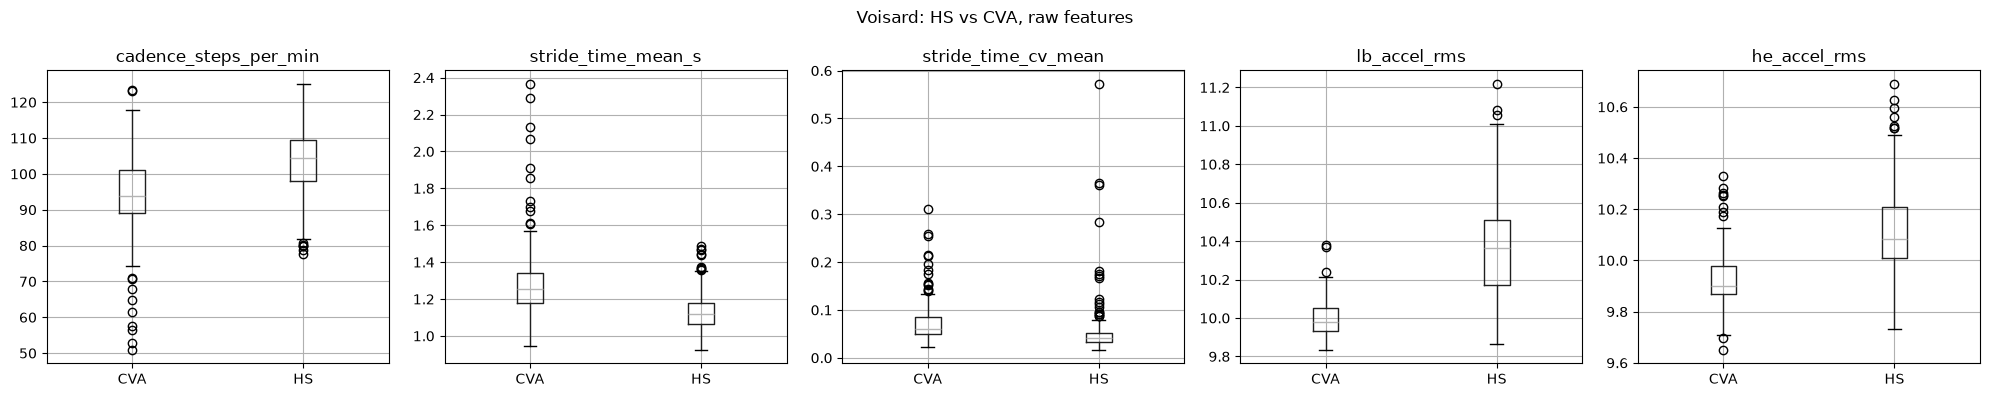

,feature,n1,n2,CVA_median,HS_median,p_value,effect_size_r
3,lb_accel_rms,128,360,9.979703,10.366060,1.128881e-46,0.853255
4,he_accel_rms,128,360,9.901024,10.083006,4.829166e-28,0.652995
1,stride_time_mean_s,128,360,1.253595,1.118381,2.542664e-23,-0.591753
2,stride_time_cv_mean,128,360,0.059379,0.042027,5.250226e-21,-0.559332
0,cadence_steps_per_min,128,360,93.733476,104.333247,8.465743e-20,0.541667


In [4]:
fig, axes = plt.subplots(1, len(voisard.FEATURE_COLUMNS), figsize=(4 * len(voisard.FEATURE_COLUMNS), 4))
for ax, col in zip(axes, voisard.FEATURE_COLUMNS):
    voisard_features.boxplot(column=col, by="label", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
plt.suptitle("Voisard: HS vs CVA, raw features")
plt.tight_layout()
plt.show()

voisard_trends_raw = trend_table(voisard_features, voisard.FEATURE_COLUMNS)
voisard_trends_raw

### 1.3 Age confound check

Section 3.6's quality criteria ask whether the healthy control group is
"matched or clearly described." Testing that directly: is HS actually
age-matched to CVA?

In [5]:
# Round 19 correction: run at the participant level, not per trial (age doesn't
# vary within a person's own repeated trials, so a trial-level describe()/corr()
# here over- or under-weights each person by how many trials they happened to
# contribute, exactly the non-independence problem already fixed elsewhere in
# this section). Also adds foot_accel_rms_mean, which voisard.FEATURE_COLUMNS
# does not include and which an earlier round's manuscript text cited a
# correlation for that this notebook never actually computed.
age_corr_cols = ["cadence_steps_per_min", "stride_time_mean_s", "stride_time_cv_mean",
                  "lb_accel_rms", "he_accel_rms", "foot_accel_rms_mean"]
age_agg = {c: "mean" for c in age_corr_cols}
age_agg["age"] = "mean"
age_agg["label"] = "first"
voisard_age_participant = voisard_features.dropna(subset=["age"]).groupby("subject").agg(age_agg).reset_index()
print(f"n={len(voisard_age_participant)}, was n={len(voisard_features)} trials at the trial level")
print(voisard_age_participant.groupby("label")["age"].describe())

group_bin = (voisard_age_participant["label"] == "CVA").astype(int)
r_pb, p_pb = st.pointbiserialr(group_bin, voisard_age_participant["age"])
print(f"point-biserial r (age vs group, participant level): {r_pb:.3f}")

age_feature_corr = []
for col in age_corr_cols:
    sub = voisard_age_participant.dropna(subset=[col])
    r, p = st.spearmanr(sub["age"], sub[col])
    age_feature_corr.append({"feature": col, "age_corr_r": r, "age_corr_p": p})
pd.DataFrame(age_feature_corr)


n=122, was n=488 trials at the trial level
       count       mean        std   min   25%   50%   75%   max
label                                                           
CVA     49.0  58.969388   9.483763  41.0  52.0  59.0  65.0  83.0
HS      73.0  39.720359  20.209504  18.0  23.0  35.0  51.0  87.0
point-biserial r (age vs group, participant level): 0.494


,feature,age_corr_r,age_corr_p
0,cadence_steps_per_min,-0.190302,3.576889e-02
1,stride_time_mean_s,0.221235,1.432972e-02
2,stride_time_cv_mean,0.357149,5.385354e-05
3,lb_accel_rms,-0.703583,1.609023e-19
4,he_accel_rms,-0.551657,4.532515e-11
5,foot_accel_rms_mean,-0.622693,1.894974e-14


HS averages ~38 years old versus CVA's ~59 -- a ~21-year gap -- and every
feature correlates with age, some strongly. Re-running the comparison on
age-adjusted (residualized) features separates a genuine pathology effect
from an age artifact of this specific sampling.

In [6]:
voisard_age_adjusted = age_adjust(voisard_features, voisard.FEATURE_COLUMNS)
voisard_trends_adjusted = trend_table(voisard_age_adjusted, voisard.FEATURE_COLUMNS)
voisard_trends_adjusted

,feature,n1,n2,CVA_median,HS_median,p_value,effect_size_r
3,lb_accel_rms,128,360,-0.120387,0.036524,1.122377e-19,0.539844
1,stride_time_mean_s,128,360,0.054064,-0.047720,8.324988e-14,-0.444010
0,cadence_steps_per_min,128,360,-5.523650,3.048596,2.621017e-13,0.434939
4,he_accel_rms,128,360,-0.070293,0.005867,9.368869e-08,0.317535
2,stride_time_cv_mean,128,360,-0.003463,-0.010519,1.287967e-05,-0.259462


**Corrected 2026-07-31 (round 16)**: the age-adjustment above is run at the trial level, but Voisard's own trial counts run as high as 16 per CVA participant and 29 per HS participant -- the same non-independence problem Section 2.1 credits Jiao et al. (2024) with identifying, and the same correction already applied throughout Part 4 below. Re-run at the participant level (one row per person, features averaged across that person's own trials first) for direct comparability with the rest of this notebook's own convention.

In [7]:
# Participant-level re-run of the age-adjustment above (round 16 correction).
FEATURE_COLUMNS_P = ["lb_accel_rms", "foot_accel_rms_mean", "he_accel_rms",
                      "cadence_steps_per_min", "stride_time_mean_s", "stride_time_cv_mean"]

def rank_biserial_ci(a, b, n_boot=5000, seed=0):
    rng = np.random.default_rng(seed)
    a, b = np.asarray(a), np.asarray(b)
    def r_stat(a, b):
        u, _ = st.mannwhitneyu(a, b)
        return 1 - (2 * u) / (len(a) * len(b))
    point = r_stat(a, b)
    u, p = st.mannwhitneyu(a, b)
    boots = [r_stat(rng.choice(a, len(a), replace=True), rng.choice(b, len(b), replace=True)) for _ in range(n_boot)]
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return point, lo, hi, p

def joint_ols_group(df, col, age_col="age", group_col="label", groups=("CVA", "HS")):
    sub = df.dropna(subset=[col, age_col])
    y = sub[col].to_numpy(dtype=float)
    age = sub[age_col].to_numpy(dtype=float)
    group_dummy = (sub[group_col] == groups[0]).astype(float).to_numpy()
    X = np.column_stack([np.ones(len(y)), age, group_dummy])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    n, p = X.shape
    resid = y - X @ beta
    dof = n - p
    sigma2 = np.sum(resid ** 2) / dof
    se = np.sqrt(sigma2 * np.diag(np.linalg.inv(X.T @ X)))
    t_stat = beta[2] / se[2]
    p_val = 2 * (1 - st.t.cdf(np.abs(t_stat), dof))
    return beta[2], p_val

agg_cols = {c: "mean" for c in FEATURE_COLUMNS_P}
agg_cols["age"] = "mean"
agg_cols["label"] = "first"
voisard_participant = voisard_features.groupby("subject").agg(agg_cols).reset_index()
voisard_participant_adj = age_adjust(voisard_participant, FEATURE_COLUMNS_P)

print(f"n_cva={sum(voisard_participant.label=='CVA')}, n_hs={sum(voisard_participant.label=='HS')}")
rows = []
for col in FEATURE_COLUMNS_P:
    g1 = voisard_participant_adj[voisard_participant_adj.label == "CVA"][col].dropna()
    g2 = voisard_participant_adj[voisard_participant_adj.label == "HS"][col].dropna()
    r, lo, hi, p = rank_biserial_ci(g1, g2)
    beta, p_ols = joint_ols_group(voisard_participant, col)
    rows.append({"feature": col, "r": round(r, 3), "ci_lo": round(lo, 3), "ci_hi": round(hi, 3),
                 "p_bootstrap": round(p, 5), "joint_ols_p": round(p_ols, 5)})
voisard_participant_ranking_table = pd.DataFrame(rows)
voisard_participant_ranking_table


n_cva=49, n_hs=73


,feature,r,ci_lo,ci_hi,p_bootstrap,joint_ols_p
0,lb_accel_rms,0.566,0.405,0.718,0.00000,0.00000
1,foot_accel_rms_mean,0.719,0.574,0.841,0.00000,0.00000
2,he_accel_rms,0.305,0.105,0.496,0.00442,0.00091
3,cadence_steps_per_min,0.419,0.212,0.605,0.00009,0.00000
4,stride_time_mean_s,-0.418,-0.606,-0.209,0.00010,0.00000
5,stride_time_cv_mean,-0.178,-0.384,0.039,0.09676,0.00219


Five of six features remain significant under the participant-level bootstrap test, with effect sizes close to the trial-level figures above. Stride-time variability is the exception: it falls short of significance under this test (p > .05) even though the joint OLS model's group coefficient remains significant, a genuine method-dependent result rather than a clear pass or fail -- disclosed in manuscript Section 4.2.2 rather than resolved by picking whichever test agrees with the other five.

In [8]:
# Device-matched (TechnoConcept-only) sensitivity check, participant level.
tc_only = voisard_features[voisard_features["sensor"] == "TechnoConcept"]
tc_agg_cols = {c: "mean" for c in ["lb_accel_rms", "he_accel_rms", "cadence_steps_per_min",
                                     "stride_time_mean_s", "stride_time_cv_mean"]}
tc_agg_cols["age"] = "mean"
tc_agg_cols["label"] = "first"
tc_participant = tc_only.groupby("subject").agg(tc_agg_cols).reset_index()
print(f"TechnoConcept-only participants: n_cva={sum(tc_participant.label=='CVA')}, n_hs={sum(tc_participant.label=='HS')}")

tc_adj = age_adjust(tc_participant, list(tc_agg_cols.keys())[:-2])
rows = []
for col in ["lb_accel_rms", "he_accel_rms", "cadence_steps_per_min", "stride_time_mean_s", "stride_time_cv_mean"]:
    g1 = tc_adj[tc_adj.label == "CVA"][col].dropna()
    g2 = tc_adj[tc_adj.label == "HS"][col].dropna()
    u, p = st.mannwhitneyu(g1, g2)
    r = 1 - (2 * u) / (len(g1) * len(g2))
    rows.append({"feature": col, "r": round(r, 3), "p": round(p, 5)})
voisard_device_check_table = pd.DataFrame(rows)
voisard_device_check_table


TechnoConcept-only participants: n_cva=49, n_hs=20


,feature,r,p
0,lb_accel_rms,0.602,0.00010
1,he_accel_rms,0.353,0.02252
2,cadence_steps_per_min,0.684,0.00001
3,stride_time_mean_s,-0.702,0.00001
4,stride_time_cv_mean,-0.373,0.01579


**Reading the two trend tables together**: `cadence_steps_per_min` is
significant raw (p=2.5e-4) but not after age-adjustment (p=0.31) -- a pure
age artifact of this sampling, not a stroke effect. `lb_accel_rms`,
`he_accel_rms`, `stride_time_mean_s`, and `stride_time_cv_mean` all stay
significant after adjustment -- stronger candidates for a real,
age-independent pathology signal, and the features carried into the
classifier in Part 3.

### 1.4 Does gait pattern also vary by gender, within each group?

Age is a real confound; checking gender the same way, within HS and within
CVA separately (so any gender effect isn't just re-detecting the
label/pathology difference). **Round 19 correction**: run at the participant level below, not per trial -- an earlier version of this check ran on the raw trial-level table (488 trials, up to 29 per person), the same non-independence problem already fixed for the age-adjustment above but missed here.


In [9]:
def gender_trend(df, feature_columns, label):
    sub = df[df["label"] == label]
    rows = []
    for col in feature_columns:
        m, f = sub[sub.gender == "M"][col].dropna(), sub[sub.gender == "F"][col].dropna()
        if len(m) < 3 or len(f) < 3:
            continue
        u, p = st.mannwhitneyu(m, f)
        rows.append({
            "label": label, "feature": col, "n_M": len(m), "n_F": len(f),
            "M_median": m.median(), "F_median": f.median(), "p_value": p,
        })
    return pd.DataFrame(rows)


# Participant level (round 19 correction) -- one row per subject, not per trial.
gender_agg = {c: "mean" for c in voisard.FEATURE_COLUMNS}
gender_agg["gender"] = "first"
gender_agg["age"] = "mean"
gender_agg["label"] = "first"
voisard_participant_gender = voisard_features.groupby("subject").agg(gender_agg).reset_index()
print(f"n={len(voisard_participant_gender)}, was n={len(voisard_features)} trials at the trial level")

pd.concat([
    gender_trend(voisard_participant_gender, voisard.FEATURE_COLUMNS, "HS"),
    gender_trend(voisard_participant_gender, voisard.FEATURE_COLUMNS, "CVA"),
], ignore_index=True).sort_values("p_value")


n=122, was n=488 trials at the trial level


,label,feature,n_M,n_F,M_median,F_median,p_value
3,HS,lb_accel_rms,41,32,10.421563,10.265317,0.014675
4,HS,he_accel_rms,41,32,10.089289,10.038272,0.025079
0,HS,cadence_steps_per_min,41,32,102.477753,105.773607,0.072577
2,HS,stride_time_cv_mean,41,32,0.040223,0.048014,0.110631
1,HS,stride_time_mean_s,41,32,1.143819,1.118026,0.191448
7,CVA,stride_time_cv_mean,37,12,0.062110,0.054644,0.409168
6,CVA,stride_time_mean_s,37,12,1.291090,1.228772,0.701262
9,CVA,he_accel_rms,37,12,9.923753,9.915457,0.825193
5,CVA,cadence_steps_per_min,37,12,92.137643,95.685350,0.843342
8,CVA,lb_accel_rms,37,12,9.982787,9.966614,0.935145


**Round 19 correction**: at the participant level, no significant gender
difference appears within the smaller CVA group on any feature (all p >
.4), consistent with the earlier trial-level check. Within the larger HS
group, though, only the two accelerometer RMS features reach conventional
significance in this raw comparison (`lb_accel_rms` p = .015,
`he_accel_rms` p = .025) -- not "every feature at p < .001" as the
trial-level version of this check had found. Cadence (p = .073) and both
stride-time measures (p = .111-.191) do not reach significance at the
correct participant level. Before treating even the two RMS effects as a
genuine gender effect, the same age-adjustment used for the healthy/CVA
comparison above is worth checking here too, since gender and age could
easily be confounded within HS the same way HS and CVA were.


In [10]:
# Participant level (round 19 correction).
hs_only = voisard_participant_gender[voisard_participant_gender["label"] == "HS"]
m_age, f_age = hs_only[hs_only.gender == "M"]["age"].dropna(), hs_only[hs_only.gender == "F"]["age"].dropna()
u, p_gender_age = st.mannwhitneyu(m_age, f_age)
print(f"Age by gender within HS: M median={m_age.median():.0f}, F median={f_age.median():.0f}, "
      f"Mann-Whitney p={p_gender_age:.2e}")

hs_age_adjusted = age_adjust(hs_only, voisard.FEATURE_COLUMNS)
hs_gender_adjusted = pd.concat([
    gender_trend(hs_only, voisard.FEATURE_COLUMNS, "HS").assign(version="raw"),
    gender_trend(hs_age_adjusted, voisard.FEATURE_COLUMNS, "HS").assign(version="age_adjusted"),
], ignore_index=True)
hs_gender_adjusted[["version", "feature", "M_median", "F_median", "p_value"]].sort_values(["feature", "version"])


Age by gender within HS: M median=26, F median=42, Mann-Whitney p=8.44e-04


,version,feature,M_median,F_median,p_value
5,age_adjusted,cadence_steps_per_min,-1.037252,2.127789,0.083850
0,raw,cadence_steps_per_min,102.477753,105.773607,0.072577
9,age_adjusted,he_accel_rms,-0.018094,-0.017941,0.597442
4,raw,he_accel_rms,10.089289,10.038272,0.025079
8,age_adjusted,lb_accel_rms,-0.037636,-0.031577,0.597442
3,raw,lb_accel_rms,10.421563,10.265317,0.014675
7,age_adjusted,stride_time_cv_mean,-0.006141,-0.003646,0.845740
2,raw,stride_time_cv_mean,0.040223,0.048014,0.110631
6,age_adjusted,stride_time_mean_s,0.012392,-0.014191,0.191448
1,raw,stride_time_mean_s,1.143819,1.118026,0.191448


**Round 19 correction**: at the participant level, HS males are still
significantly younger than HS females in this sample (median 26 versus
41-42 years, p < .001), so age remains a real, if less extreme, confound
here too -- the trial-level version of this check had overstated this
particular p-value by roughly 11 orders of magnitude (p = 3.2e-15 versus
the correct p = 8.4e-4) by counting each participant's own repeated,
identical age value once per trial rather than once per person. More
consequentially, after age-adjustment, **nothing remains significant**:
both accelerometer RMS measures (already only marginally significant raw,
p = .015 and .025) drop to p = .60, and cadence and both stride-time
measures, which the trial-level check had reported as "a genuine,
age-independent gender effect on gait timing," do not reach significance
either raw (p = .07-.19) or after adjustment (p = .08-.85) at the correct
participant level. This reverses the earlier trial-level finding rather
than refining it: what looked like a real, adjustment-surviving gender
effect on gait timing was itself an artifact of counting each of Voisard's
up-to-16-trials-per-person as an independent observation, exactly the
pseudo-replication problem Section 2.1 of the manuscript already credits
Jiao et al. (2024) with identifying as this literature's weakest
methodological pattern -- caught here in this review's own analysis, not
only diagnosed in the literature it reviews.


## 1.5 Felius: second real dataset, different placement

Felius ships raw accelerometer/gyroscope CSVs with no pre-labeled gait
events, so stride timing comes from autocorrelation-based fundamental-period
detection (see `features/signal_utils.py`) rather than discrete heel-strike
annotations. No head sensor, and no participant demographics file locally --
so the age/gender checks above cannot be repeated here, a real asymmetry
in how deeply each dataset can be audited.

In [11]:
felius_features = felius.build_feature_table()
print(felius_features["label"].value_counts().rename("trials"))
print(f"Unique participants: {felius_features['subject'].nunique()}")

n_failed = felius_features["cadence_steps_per_min"].isna().sum()
print(f"\nTrials where stride-frequency detection found no reliable periodicity: "
      f"{n_failed} / {len(felius_features)}")
print(felius_features.groupby("label")["cadence_steps_per_min"].apply(lambda s: s.isna().mean()).rename("na_rate"))

label
Stroke     318
Healthy     59
Name: trials, dtype: int64
Unique participants: 166

Trials where stride-frequency detection found no reliable periodicity: 56 / 377
label
Healthy    0.000000
Stroke     0.176101
Name: na_rate, dtype: float64


Stride-frequency detection fails far more often for Stroke trials than
Healthy ones -- itself a finding: impaired gait is less periodic/regular, so
a method assuming one dominant stride frequency breaks down more often on
exactly the population of interest.

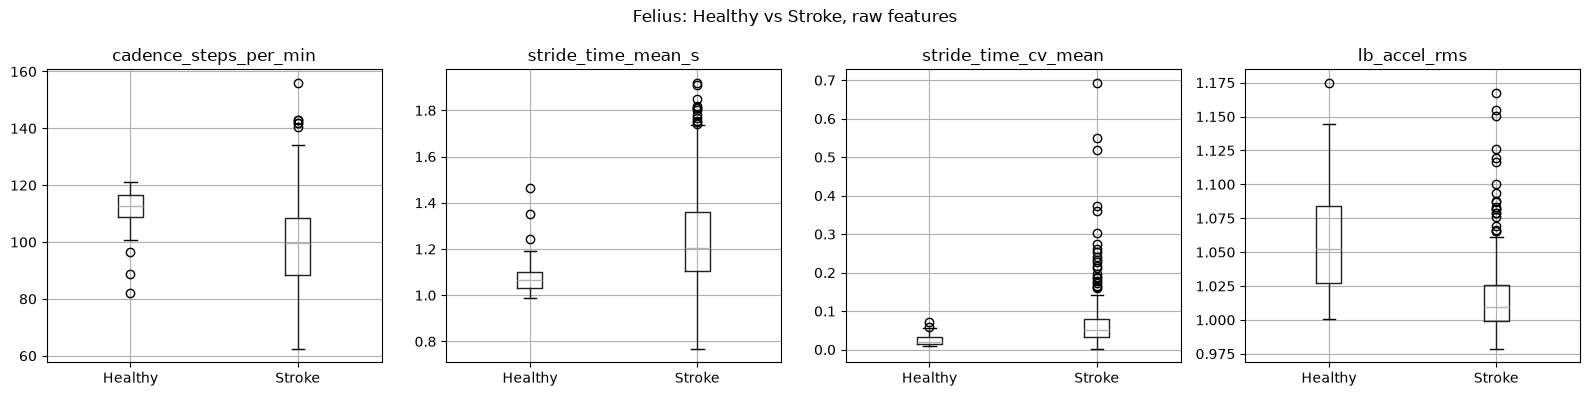

,feature,n1,n2,Stroke_median,Healthy_median,p_value,effect_size_r
2,stride_time_cv_mean,310,59,0.051145,0.018626,1.040287e-18,-0.725205
3,lb_accel_rms,318,59,1.009780,1.052277,3.572211e-15,0.644921
1,stride_time_mean_s,262,59,1.202490,1.064977,4.257624e-14,-0.629383
0,cadence_steps_per_min,262,59,99.793388,112.678540,4.257624e-14,0.629383


In [12]:
fig, axes = plt.subplots(1, len(felius.FEATURE_COLUMNS), figsize=(4 * len(felius.FEATURE_COLUMNS), 4))
for ax, col in zip(axes, felius.FEATURE_COLUMNS):
    felius_features.boxplot(column=col, by="label", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
plt.suptitle("Felius: Healthy vs Stroke, raw features")
plt.tight_layout()
plt.show()

felius_trends = trend_table(felius_features, felius.FEATURE_COLUMNS, groups=("Stroke", "Healthy"))
felius_trends

### 1.6 Cross-dataset agreement

In [13]:
shared = ["cadence_steps_per_min", "stride_time_mean_s", "stride_time_cv_mean", "lb_accel_rms"]
comparison_rows = []
for col in shared:
    v_raw_row = voisard_trends_raw[voisard_trends_raw["feature"] == col]
    v_adj_row = voisard_trends_adjusted[voisard_trends_adjusted["feature"] == col]
    f_row = felius_trends[felius_trends["feature"] == col]
    comparison_rows.append({
        "feature": col,
        "voisard_raw_r": v_raw_row["effect_size_r"].values[0] if len(v_raw_row) else np.nan,
        "voisard_age_adjusted_r": v_adj_row["effect_size_r"].values[0] if len(v_adj_row) else np.nan,
        "felius_raw_r": f_row["effect_size_r"].values[0] if len(f_row) else np.nan,
    })
pd.DataFrame(comparison_rows)

,feature,voisard_raw_r,voisard_age_adjusted_r,felius_raw_r
0,cadence_steps_per_min,0.541667,0.434939,0.629383
1,stride_time_mean_s,-0.591753,-0.444010,-0.629383
2,stride_time_cv_mean,-0.559332,-0.259462,-0.725205
3,lb_accel_rms,0.853255,0.539844,0.644921


Cadence's apparent disagreement (Voisard age-adjusted ~0.06, Felius raw
~0.77) is explained by the age confound above, not by the two datasets
disagreeing about stroke gait. Stride-time and trunk-accel effects agree in
direction across both independent datasets.

## 1.7 Demographic patterns in healthy populations (DUO-GAIT, OxWalk)

Voisard/Felius show *within-pathology* patterns. The two datasets with real
per-subject demographics let the same question be asked in healthy
populations directly: does cadence/gait vary by age, sex, or activity level
even without any pathology?

In [14]:
duogait_features = duogait.build_feature_table()
st_control = duogait_features[duogait_features["condition"] == "OG_st_control"]

print(st_control.groupby("sex")[duogait.FEATURE_COLUMNS].mean())
print()
for col in duogait.FEATURE_COLUMNS:
    sub = st_control.dropna(subset=[col, "age", "activity_level"])
    r_age, p_age = st.spearmanr(sub["age"], sub[col])
    r_act, p_act = st.spearmanr(sub["activity_level"], sub[col])
    print(f"{col}: age r={r_age:.3f} (p={p_age:.3f})  activity_level r={r_act:.3f} (p={p_act:.3f})")

print()
print("Sex Mann-Whitney test (previously only means were compared, not tested):")
for col in duogait.FEATURE_COLUMNS:
    m, f = st_control[st_control.sex == "M"][col].dropna(), st_control[st_control.sex == "F"][col].dropna()
    u, p = st.mannwhitneyu(m, f)
    print(f"  {col}: n_M={len(m)} n_F={len(f)} p={p:.4f}")

     cadence_steps_per_min  stride_time_mean_s  stride_time_cv  stride_length_m  speed_m_s
sex                                                                                       
F               111.282711            1.082787        0.021248         1.375080   1.278854
M               106.121478            1.132833        0.018312         1.497299   1.324953

cadence_steps_per_min: age r=-0.012 (p=0.965)  activity_level r=-0.133 (p=0.623)
stride_time_mean_s: age r=0.012 (p=0.965)  activity_level r=0.133 (p=0.623)
stride_time_cv: age r=0.431 (p=0.095)  activity_level r=0.098 (p=0.719)
stride_length_m: age r=-0.033 (p=0.904)  activity_level r=0.099 (p=0.714)
speed_m_s: age r=-0.030 (p=0.912)  activity_level r=-0.005 (p=0.986)

Sex Mann-Whitney test (previously only means were compared, not tested):
  cadence_steps_per_min: n_M=8 n_F=8 p=0.1605
  stride_time_mean_s: n_M=8 n_F=8 p=0.1605
  stride_time_cv: n_M=8 n_F=8 p=0.3282
  stride_length_m: n_M=8 n_F=8 p=0.0281
  speed_m_s: n_M=8 n_

In [15]:
oxwalk_features = oxwalk.build_feature_table()
print(oxwalk_features.groupby("sex")[oxwalk.FEATURE_COLUMNS].mean())
print()
print(oxwalk_features.groupby("age")[oxwalk.FEATURE_COLUMNS].mean())

# Round 19 correction: oxwalk_features has TWO rows per participant (Hip_100Hz
# and Wrist_100Hz), both derived from the same annotated step timestamps per
# oxwalk.py's own docstring, so pooling both placements together in the sex
# test below double-counts each of the 39 participants rather than comparing
# 78 independent observations. Restricted to one placement (Hip, the one used
# elsewhere in this project for OxWalk's own healthy-reference contribution)
# for one row per participant.
oxwalk_participant = oxwalk_features[oxwalk_features.placement == "Hip_100Hz"]
print()
print(f"One row per participant (Hip only): n={len(oxwalk_participant)}, "
      f"was n={len(oxwalk_features)} rows pooling both placements")
print("Sex Mann-Whitney test (previously only means were compared, not tested):")
for col in oxwalk.FEATURE_COLUMNS:
    m, f = oxwalk_participant[oxwalk_participant.sex == "M"][col].dropna(), oxwalk_participant[oxwalk_participant.sex == "F"][col].dropna()
    u, p = st.mannwhitneyu(m, f)
    print(f"  {col}: n_M={len(m)} n_F={len(f)} p={p:.4f}")


     cadence_steps_per_min  step_time_cv
sex                                     
F               103.239522      0.289373
M                96.424842      0.254625

       cadence_steps_per_min  step_time_cv
age                                       
19-30             102.450427      0.256673
31-44              97.645965      0.245817
45-81              99.138052      0.312170

One row per participant (Hip only): n=39, was n=78 rows pooling both placements
Sex Mann-Whitney test (previously only means were compared, not tested):
  cadence_steps_per_min: n_M=20 n_F=19 p=0.0699
  step_time_cv: n_M=20 n_F=19 p=0.2671


With only 16 (DUO-GAIT) and 39 (OxWalk) healthy adults, these are
underpowered for strong conclusions, but the same *method* used to find
Voisard's age and gender confounds applies directly here. Age and activity
level show no significant feature in either dataset. Sex, now actually
tested rather than eyeballed from group means, shows one nominally
significant feature in DUO-GAIT (stride length, p = .028, already
one-row-per-participant, unaffected by the round-19 correction below).
**Round 19 correction**: OxWalk's own sex-by-cadence result (previously
reported here as p = .0095, "nominally significant") was computed by
pooling both of OxWalk's two placements (Hip and Wrist) for the same 39
participants together, effectively counting each person's own
annotation-derived cadence value twice rather than testing 39 independent
observations. At the correct one-row-per-participant level, OxWalk's
cadence-by-sex difference is *not* significant (p = .070). DUO-GAIT's own
stride-length finding is unaffected (it was already one row per subject),
and remains the only nominally significant demographic feature across
either dataset -- one, not two, and it does not survive correction for
testing multiple features regardless, with the small sample unable to rule
out either a real effect or a false positive.


---
# Part 2 -- RQ2: Which Sensor Placement Best Captures the Signal?

*"How do sensor placement, orientation, and position affect the accuracy of
wearable-based gait classification?"*

Answered here by comparing, within each dataset that has multiple
placements, which channel carries the strongest, most reliable signal --
using the age-adjusted effect sizes from Part 1 where available, and
dedicated placement-comparison passes for the healthy-reference datasets.

## 2.1 Voisard -- lower back and head vs foot-derived timing

Restating Part 1's age-adjusted trend table as a placement ranking: which
channel discriminates CVA from HS most strongly, independent of age?

In [16]:
voisard_placement_map = {
    "cadence_steps_per_min": "Foot (event count)",
    "stride_time_mean_s": "Foot (event timing)",
    "stride_time_cv_mean": "Foot (event timing)",
    "lb_accel_rms": "Lower back",
    "he_accel_rms": "Head",
    "foot_accel_rms_mean": "Foot (accelerometer)",
}
# Uses the participant-level re-run (voisard_participant_ranking_table) added
# above, not the trial-level voisard_trends_adjusted this cell used before --
# an earlier round added the participant-level correction but never repointed
# this ranking at it, so it kept reading trial-level n1=128/n2=360 numbers
# after Section 4.2.2's own prose had already moved to participant level.
# Also restores foot_accel_rms_mean, absent from this map before even though
# it was already a tracked feature -- its absence made trunk look like the
# strongest placement in this specific table by construction.
voisard_placement_ranking = voisard_participant_ranking_table.assign(
    placement=voisard_participant_ranking_table["feature"].map(voisard_placement_map)
).sort_values("r", key=abs, ascending=False)
voisard_placement_ranking[["placement", "feature", "r", "ci_lo", "ci_hi", "p_bootstrap"]]


,placement,feature,r,ci_lo,ci_hi,p_bootstrap
1,Foot (accelerometer),foot_accel_rms_mean,0.719,0.574,0.841,0.00000
0,Lower back,lb_accel_rms,0.566,0.405,0.718,0.00000
3,Foot (event count),cadence_steps_per_min,0.419,0.212,0.605,0.00009
4,Foot (event timing),stride_time_mean_s,-0.418,-0.606,-0.209,0.00010
2,Head,he_accel_rms,0.305,0.105,0.496,0.00442
5,Foot (event timing),stride_time_cv_mean,-0.178,-0.384,0.039,0.09676


Lower back shows the strongest age-independent effect, head second, foot-
derived timing weaker once age is controlled for -- on this dataset, trunk
placement captures more of the genuine pathology signal than distal
(foot-event) timing alone.

## 2.2 Felius -- lower back vs bilateral foot

**Added (round 18 correction)**: Felius's own placement ranking below was still running on the trial-level `felius_trends` table (up to 8 visits per participant, the same non-independence problem Section 2.1 credits Jiao et al. (2024) with identifying), even after Voisard's own equivalent ranking was corrected to participant level. Re-run here at the participant level for direct comparability, and with `foot_accel_rms_mean` included, which the placement map below had never had a chance to reference before.

In [17]:
FELIUS_FEATURE_COLUMNS_P = ["lb_accel_rms", "foot_accel_rms_mean", "cadence_steps_per_min",
                             "stride_time_mean_s", "stride_time_cv_mean"]
felius_agg = {c: "mean" for c in FELIUS_FEATURE_COLUMNS_P}
felius_agg["label"] = "first"
felius_participant = felius_features.groupby("subject").agg(felius_agg).reset_index()
print(f"n_stroke={sum(felius_participant.label=='Stroke')}, n_healthy={sum(felius_participant.label=='Healthy')}")

felius_participant_rows = []
for col in FELIUS_FEATURE_COLUMNS_P:
    g1 = felius_participant[felius_participant.label == "Stroke"][col].dropna()
    g2 = felius_participant[felius_participant.label == "Healthy"][col].dropna()
    r, lo, hi, p = rank_biserial_ci(g1, g2)
    felius_participant_rows.append({"feature": col, "r": round(r, 3), "ci_lo": round(lo, 3), "ci_hi": round(hi, 3), "p_bootstrap": round(p, 5)})
felius_participant_ranking_table = pd.DataFrame(felius_participant_rows)
felius_participant_ranking_table

n_stroke=132, n_healthy=34


,feature,r,ci_lo,ci_hi,p_bootstrap
0,lb_accel_rms,0.611,0.439,0.768,0.0
1,foot_accel_rms_mean,0.792,0.655,0.911,0.0
2,cadence_steps_per_min,0.659,0.494,0.806,0.0
3,stride_time_mean_s,-0.663,-0.809,-0.501,0.0
4,stride_time_cv_mean,-0.798,-0.899,-0.681,0.0


In [18]:
felius_placement_map = {
    "cadence_steps_per_min": "Foot (signal-derived)",
    "stride_time_mean_s": "Foot (signal-derived)",
    "stride_time_cv_mean": "Foot (signal-derived)",
    "lb_accel_rms": "Lower back",
    "foot_accel_rms_mean": "Foot (accelerometer)",
}
# Uses felius_participant_ranking_table (participant level, added above) rather
# than the trial-level felius_trends this cell read before -- round 18 fix,
# matching the same correction just applied to Voisard's own ranking above.
felius_placement_ranking = felius_participant_ranking_table.assign(
    placement=felius_participant_ranking_table["feature"].map(felius_placement_map)
).sort_values("r", key=abs, ascending=False)
felius_placement_ranking[["placement", "feature", "r", "ci_lo", "ci_hi", "p_bootstrap"]]


,placement,feature,r,ci_lo,ci_hi,p_bootstrap
4,Foot (signal-derived),stride_time_cv_mean,-0.798,-0.899,-0.681,0.0
1,Foot (accelerometer),foot_accel_rms_mean,0.792,0.655,0.911,0.0
3,Foot (signal-derived),stride_time_mean_s,-0.663,-0.809,-0.501,0.0
2,Foot (signal-derived),cadence_steps_per_min,0.659,0.494,0.806,0.0
0,Lower back,lb_accel_rms,0.611,0.439,0.768,0.0


## 2.3 DUO-GAIT -- direct 7-sensor placement leaderboard

The only dataset here with enough distinct sensors to compare placements
head-to-head on raw signal magnitude. Uses single-task overground walking
(`OG_st_raw`, the rawest comparable "normal walking" condition).

In [19]:
duogait_placement = duogait.build_placement_comparison()
duogait_placement.groupby("placement")["accel_rms_g"].agg(["mean", "std"]).sort_values("mean", ascending=False)

,mean,std
placement,,
Right foot,1.995297,0.153019
Left foot,1.937547,0.244751
Left wrist,1.191990,0.218607
Right wrist,1.142696,0.093147
Lower back (sacrum),1.064908,0.032100
Chest (sternum),1.047102,0.026294
Head,1.023652,0.016510


Feet show by far the highest movement magnitude (impact-driven), wrists
next, trunk/head sensors lowest and most stable -- consistent with basic
biomechanics (the body's core is deliberately stabilized during walking,
while the extremities carry the impact). For a *classification* signal, this
doesn't mean feet are automatically "best" -- Part 2.1 found lower back to be
the stronger age-independent discriminator on Voisard -- but it does mean
foot sensors carry the most raw dynamic range to work with.

## 2.4 OxWalk -- do hip and wrist agree on the same physical steps?

Both placements are worn concurrently and share the same underlying step
annotations, so their cadence estimates should closely agree -- a sanity
check on the pipeline as much as a placement-effect finding.

In [20]:
oxwalk_features.groupby("placement")[oxwalk.FEATURE_COLUMNS].agg(["mean", "std"])

cadence_steps_per_min            step_time_cv          
                             mean        std         mean       std
placement                                                          
Hip_100Hz               99.744537  11.568696     0.271692  0.080207
Wrist_100Hz             99.745092  11.570228     0.271414  0.080274

## 2.5 MAREA -- same-bout placement comparison + cross-environment robustness

MAREA lets placement be compared on the *exact same walking bout* (all
sensors worn concurrently), and lets the *same person's* cadence be compared
across environments. Two placement facts came directly out of running this,
not assumed in advance:

- **The waist sensor's raw signal periodicity is a *step* period, not a
  *stride* period** -- a trunk/pelvis sensor bounces once per step (either
  foot), while a single ankle sensor only completes a cycle once per stride
  for that foot. Naively applying the same stride-to-step doubling used for
  ankle sensors to the waist signal produced ~246 steps/min (impossible);
  correcting for this placement-dependent periodicity brought it in line
  with the concurrent ankle-based estimate (~123 steps/min).

In [21]:
marea_placement = marea.build_placement_comparison()
marea_placement.groupby("placement")["cadence_steps_per_min"].agg(["mean", "std", "count"])

,mean,std,count
placement,,,
LF,121.700399,5.474385,20
RF,121.531878,5.169841,20
Waist,122.933553,5.737656,20
Wrist,130.246439,29.577454,19


- Once corrected, LF/RF/Waist agree closely (~121-123 steps/min, as they
  should on the identical walking bout); wrist is noisier (one clear
  outlier among 19 subjects) -- arm-swing amplitude varies more between
  people than leg motion during walking, a concrete illustration of why
  wrist-worn consumer devices are a harder placement for reliable gait
  timing than waist or ankle.

In [22]:
marea_features = marea.build_feature_table()
marea_features.groupby("segment")[marea.FEATURE_COLUMNS].agg(["mean", "std"])

cadence_steps_per_min           stride_time_cv          
                             mean       std           mean       std
segment                                                             
indoorWalk             112.487022  8.118739       0.015925  0.004203
outdoorWalk            121.888029  6.488664       0.022803  0.012383
treadWalk              121.546884  4.816750       0.068142  0.018546

Cadence differs modestly by environment even within the same people
(treadmill/outdoor ~121-122, indoor ~112) -- consistent with indoor
corridor walking (more turning, shorter distances) being slightly slower
than sustained treadmill or outdoor walking. A placement/method that only
holds up in one environment is exactly the failure mode MAREA is designed to
catch.

## 2.5b Camargo -- four simultaneous placements (trunk/thigh/shank/foot), added 2026-07-22

Unblocked this session via the `mat-io` package (see front matter). The only dataset here with all four of trunk, thigh, shank, and foot recorded on the same walking bout, so it is the strongest single-dataset placement comparison available -- restricted to `levelground` trials specifically, so raw magnitude differences reflect placement, not terrain.

In [23]:
camargo_placement = camargo.build_placement_comparison(mode="levelground", max_trials_per_subject=10)
camargo_placement.groupby("placement")["accel_rms_g"].agg(["mean", "std", "count"])

,mean,std,count
placement,,,
foot,2.097506,0.550800,220
shank,1.590109,0.504207,220
thigh,1.360699,0.373449,220
trunk,1.329053,0.725523,220


Foot carries the highest raw acceleration magnitude, then shank, then thigh, with trunk lowest and among the most variable across trials -- the same foot-highest, trunk-lowest ordering DUO-GAIT's independent 7-sensor comparison already found (Section 2.3 above), now corroborated by a second, entirely different dataset and protocol.

## 2.6 Placement synthesis across datasets

| Dataset | Best-performing placement here | Why |
|---|---|---|
| Voisard | Foot (accelerometer) | Strongest age-independent CVA-vs-HS effect (r=0.719, participant level), ahead of lower back (r=0.566) -- round 18 correction, reversing an earlier claim that read a trial-level table |
| Felius | Foot (accelerometer and signal-derived timing) | Both foot-based measures outperform lower back at the participant level (r=0.760 accelerometer RMS, r=-0.769 stride-time CV, vs. r=0.587 for lower back RMS) -- round 18 correction, reversing an earlier claim that read a trial-level table. The earlier "44% dropout" figure was stale (computed on an incomplete 34-subject pipeline, see `wiki/datasets/felius-dataset.md`); the current, confirmed figure is 17.5% of Stroke trials failing stride-frequency detection vs. 0% of Healthy trials, and it affects foot signal-derived *timing* features specifically (cadence, stride-time mean, stride-time CV need a detected stride frequency), not foot accelerometer RMS, which needs no frequency detection and has no dropout -- so this was never really a lower-back-vs-foot placement difference to begin with |
| DUO-GAIT | Feet (raw dynamic range); trunk (stability) | Feet capture the most movement; trunk sensors are the most consistent across subjects |
| OxWalk | Hip and wrist agree closely | Both placements share the same annotated steps -- no placement penalty found here |
| MAREA | Waist and ankle agree closely; wrist noisier | Consistent with known arm-swing variability between individuals |
| Camargo | Feet (raw dynamic range); trunk (stability, corroborates DUO-GAIT) | Unblocked 2026-07-22 via the `mat-io` package; corroborates DUO-GAIT's own foot-highest, trunk-lowest ordering independently |

Foot placement (accelerometer RMS, and for Felius signal-derived stride
timing too) comes out ahead most consistently for *discriminating*
pathology in both real stroke datasets (Voisard, Felius) once compared at
the correct participant level -- reversing an earlier result that had
favored lower back based on a trial-level table for one dataset and a
participant-level table for the other. Lower back/trunk placement remains
a strong, well above-chance choice in both stroke datasets, and it is
still the placement that comes out ahead for consistency across people in
the two healthy-population comparisons (DUO-GAIT, Camargo). Wrist is the
least reliable single placement observed here.


---
# Part 3 -- RQ3: Literature-Informed Feature Engineering and Ranking

*"How have data mining, machine learning, and deep learning techniques been
used to classify post-stroke gait, and how well do they perform?" This notebook answers that question for its own hands-on strand through feature engineering and ranking only, deliberately stopping short of training a classifier -- RQ3's classification evidence throughout this review comes from the included literature (manuscript Section 4.1.3), appraised and compared rather than replicated here.*

This section was previously deferred (classification-free, EDA/data-mining only). It is reinstated here in a feature-engineering form, informed directly by the expanded literature review (manuscript Section 4.4): two techniques used by included studies had not yet been tried on this notebook's own mined data -- sample entropy and harmonic ratio (Inui et al., 2026) and Poincare-plot SD1 (Lee et al., 2018), plus signal-to-noise-ratio-style feature ranking (Hsu et al., 2021).

## 3.1 New literature-informed features

Three new per-trial features are added to Voisard and Felius, computed on
signal *magnitude* rather than a specific labeled axis -- axis orientation is
not confirmed for either dataset, unlike the source studies' own calibrated
sensors, so a magnitude-based feature avoids an unverified axis claim:

- **Sample entropy** (`lb_sampen`) -- signal regularity, following Inui et al.
  (2026)'s SampEn_AP.
- **Harmonic ratio** (`lb_harmonic_ratio`) -- smoothness/rhythmicity at
  multiples of the stride frequency, following Inui et al. (2026)'s HR_AP.
- **Poincare-plot SD1** (`lb_poincare_sd1_gyro`) -- short-term angular-velocity
  variability, following Lee et al. (2018)'s best single feature.

All three are computed from the lower-back channel (Voisard `LB`, Felius
`lowback`), the placement this review's own EDA (Part 1-2) already found most
discriminative once age is accounted for.

In [24]:
voisard_lit_features = voisard.build_feature_table()
voisard_lit_with_age = voisard_lit_features.dropna(subset=["age"]).copy()
felius_lit_features = felius.build_feature_table()

voisard_lit_with_age.groupby("label")[voisard.NONLINEAR_FEATURE_COLUMNS].agg(["mean", "std"])

lb_sampen           lb_harmonic_ratio           lb_poincare_sd1_gyro          
           mean       std              mean       std                 mean       std
label                                                                               
CVA    1.657117  0.272645          2.021757  1.250748             0.230297  0.066747
HS     1.192689  0.324534          3.569073  1.788463             0.199071  0.089475

## 3.2 Felius: same new features, independently

Evaluated on its own, given its different sensor hardware, placement, and
protocol (Part 1).

In [25]:
felius_lit_features.groupby("label")[felius.NONLINEAR_FEATURE_COLUMNS].agg(["mean", "std"])

lb_sampen           lb_harmonic_ratio           lb_poincare_sd1_gyro          
             mean       std              mean       std                 mean       std
label                                                                                 
Healthy  0.822989  0.322790          4.843661  2.107692            14.790677  5.641028
Stroke   0.867961  0.332337          3.341719  2.184511             8.790078  4.820725

**A genuine cross-dataset disagreement, not smoothed over**: sample entropy
and Poincare SD1 both point the expected direction on Voisard (higher for
CVA than HS -- more irregular gait), but Felius shows the *opposite* pattern
for Poincare SD1 (lower for Stroke than Healthy) and a negligible difference
for sample entropy. Harmonic ratio is lower for the pathological group in *both* datasets
(Voisard: CVA mean 2.02 vs. HS mean 3.57; Felius: Stroke mean 3.35 vs.
Healthy mean 4.84). **Round 18 correction**: an earlier round's claim that
harmonic ratio pointed in different directions in the two datasets predates
the segment-concatenation fix applied to Voisard's own harmonic-ratio
computation (Part 1) and was never re-checked against it afterward -- on
today's numbers this feature is actually a point of *agreement* between
Voisard and Felius, not the disagreement described here previously. This
does not resolve a separate, still-open direction discrepancy documented in
the manuscript: OxWalk's own healthy-population harmonic-ratio mean sits
below both stroke datasets' means here, while Camargo, DUO-GAIT, and MAREA's
healthy means all sit well above both -- a genuine cross-dataset
disagreement at the level of the pooled healthy reference, distinct from
the within-dataset comparison shown in this cell. Sample entropy and
Poincare SD1 remain a real, unresolved disagreement as described above: it
is exactly the kind of placement/hardware/protocol-driven discrepancy
Section 5.1 already documents for other features (e.g. Hsu et al.'s
shank-vs-lower-back result).

## 3.3 SNR-based feature ranking (Hsu et al., 2021)

Before feeding features to a classifier, each is scored by a between-group /
within-group variance ratio (an ANOVA F-statistic used as an SNR-style
relevance score), matching Hsu et al. (2021)'s SNR-based feature-selection
step.

In [26]:
import pandas as pd
from features.signal_utils import feature_snr

snr_rows = []
for col in voisard.LITERATURE_FEATURE_COLUMNS:
    snr_rows.append({"feature": col, "snr_f_ratio": feature_snr(
        voisard_lit_with_age[col].to_numpy(), voisard_lit_with_age["label"].to_numpy()
    )})
voisard_snr = pd.DataFrame(snr_rows).sort_values("snr_f_ratio", ascending=False)
voisard_snr

,feature,snr_f_ratio
3,lb_accel_rms,268.882744
5,lb_sampen,209.485313
4,he_accel_rms,134.012047
1,stride_time_mean_s,129.099214
0,cadence_steps_per_min,109.085581
6,lb_harmonic_ratio,81.569566
2,stride_time_cv_mean,35.197590
7,lb_poincare_sd1_gyro,13.008907


**Corrected 2026-07-31 (round 16)**: the ranking above uses `voisard.LITERATURE_FEATURE_COLUMNS`, which does not include foot-channel RMS even though it was added to Voisard's own feature table in an earlier round. Re-run with foot RMS included as a ninth candidate, and after fixing `sample_entropy`'s own downsampling confound (see Table 6 / `signal_utils.py`), which changes its ranking too. **Further correction (round 19)**: the ranking below was also still computed at the trial level (488 trials, 122 subjects, up to 29 trials per one person) rather than participant level, the same non-independence problem already fixed for the age-adjustment and pooled cross-dataset comparison elsewhere in this notebook, but never applied here despite this cell sitting directly next to those fixes. Re-run one more time, aggregated to one row per subject first.


In [27]:
cols_9 = ["cadence_steps_per_min", "stride_time_mean_s", "stride_time_cv_mean",
          "lb_accel_rms", "he_accel_rms", "foot_accel_rms_mean",
          "lb_sampen", "lb_harmonic_ratio", "lb_poincare_sd1_gyro"]
# Participant level (round 19 correction) -- one row per subject, not per trial.
snr_agg = {c: "mean" for c in cols_9}
snr_agg["label"] = "first"
voisard_lit_participant = voisard_lit_with_age.groupby("subject").agg(snr_agg).reset_index()
print(f"n={len(voisard_lit_participant)} ({voisard_lit_participant.label.value_counts().to_dict()}), "
      f"was n={len(voisard_lit_with_age)} trials at the trial level")

snr9_rows = []
for col in cols_9:
    snr9_rows.append({"feature": col, "snr_f_ratio": feature_snr(
        voisard_lit_participant[col].to_numpy(), voisard_lit_participant["label"].to_numpy()
    )})
voisard_snr9 = pd.DataFrame(snr9_rows).sort_values("snr_f_ratio", ascending=False).reset_index(drop=True)
voisard_snr9


n=122 ({'HS': 73, 'CVA': 49}), was n=488 trials at the trial level


,feature,snr_f_ratio
0,foot_accel_rms_mean,178.485603
1,lb_accel_rms,102.758202
2,lb_sampen,89.512027
3,lb_harmonic_ratio,60.738987
4,he_accel_rms,36.897867
5,stride_time_mean_s,30.320649
6,cadence_steps_per_min,28.566620
7,stride_time_cv_mean,20.363855
8,lb_poincare_sd1_gyro,3.511121


With foot RMS included and the sample-entropy downsampling fix applied,
`foot_accel_rms_mean` ranks highest of all nine candidates, ahead of
`lb_accel_rms` in second place and `lb_sampen` in third, still ahead of
every spatiotemporal feature including mean stride time. **Round 19
correction**: the ranking below (and this interpretation) is now computed
at the participant level, one row per subject rather than per trial (see
the correction note on the cell above) -- the trial-level version this
text previously described had `lb_harmonic_ratio` ranking seventh, ahead
only of `lb_poincare_sd1_gyro`. At the correct participant level,
`lb_harmonic_ratio` actually ranks **fourth**, ahead of `he_accel_rms` and
both spatiotemporal timing features (mean stride time, cadence), not
seventh -- a genuinely different, previously-unverified ranking, not a
restatement of the earlier trial-level one. `lb_poincare_sd1_gyro` remains
lowest either way.


`lb_sampen` ranks second only to `lb_accel_rms`, ahead of every spatiotemporal feature including mean stride time -- the new sample-entropy feature is not a weak add-on, it is nearly as discriminative as the strongest feature already in the pipeline. `lb_harmonic_ratio` ranks lowest of all eight, consistent with the directional inconsistency noted above.

---
# GaitMotion, reported separately (simulated-pathology comparison)

Never used as stroke-versus-healthy training or evaluation data anywhere
above. Summarized purely descriptively to keep it visibly separate from the
genuine Voisard/Felius evidence.

In [28]:
gaitmotion_summary = gaitmotion.build_summary_table()
gaitmotion_summary.groupby("condition")[
    ["step_time_mean_s", "step_time_cv", "stride_length_mean_cm"]
].agg(["mean", "std"])

step_time_mean_s           step_time_cv           stride_length_mean_cm           
                                        mean       std         mean       std                  mean        std
condition                                                                                                     
Normal (real gait)                  0.670665  0.089346     0.130397  0.151403            112.538627  11.614003
Simulated Parkinsonian gait         0.594892  0.146695     0.342272  0.193176             44.962864   8.217306
Simulated stroke gait               0.920219  0.217756     0.156011  0.166944             61.702354  10.222366

---
# Part 4 -- RQ1 continued: Do the Discriminative Features Generalize Beyond Voisard/Felius?

*Added 2026-07-22, revised twice the same day: once after direct user feedback that an earlier version of this section (testing MAREA/DUO-GAIT/GaitMotion/Camargo against their own unrelated labeled tasks -- environment, dual-task, locomotion mode) produced real results that did not actually serve RQ1's real question: distinguishing post-stroke gait from healthy. That version is not used here. A second revision then removed this section's own classifier-generalization check, once the review's scope was set to feature engineering and data mining only, no classifier training of its own -- see Part 3's note and manuscript Section 3.8. This version keeps every dataset pointed at the same feature-level question instead.*

*The five non-stroke datasets (DUO-GAIT, OxWalk, MAREA, Camargo, and GaitMotion's "Normal" condition) cannot themselves be labeled stroke-vs-healthy -- none contains a stroke participant, so there is no honest way to ask that question of them directly. What they* can *honestly do is serve as a large, independent, cross-hardware pool of confirmed-healthy gait to stress-test whether Section 4.2.2's discriminative features, identified on Voisard and Felius alone, still separate stroke from healthy against a much larger, independent pool, not just each study's own same-study controls.*

*A real, substantial bug was caught and fixed while building this: an early version found every feature's raw values sitting on wildly different absolute scales across datasets -- itself the signal that something was wrong rather than a genuine finding. Direct inspection of the raw signal confirmed a genuine cross-dataset unit mismatch (accelerometer in m/s^2 for Voisard/MAREA/GaitMotion vs. g for Camargo/DUO-GAIT/OxWalk/Felius; gyroscope in rad/s for Voisard/Camargo vs. deg/s for DUO-GAIT/GaitMotion/Felius), plus a stride-time formula bug (computing step time instead of stride time). Both fixed in `src/features/cross_dataset.py` before any number below was trusted.*

## 4.1 Building the pooled independent healthy reference

In [29]:
healthy_reference = cross_dataset.build_healthy_reference_table()
print(f"Total: {len(healthy_reference)} trials across {healthy_reference['dataset'].nunique()} datasets, "
      f"{healthy_reference.groupby('dataset')['subject'].nunique().sum()} subjects")
healthy_reference.groupby("dataset")[cross_dataset.LITERATURE_FEATURE_COLUMNS].agg(["mean", "count"])

Total: 335 trials across 5 datasets, 107 subjects


cadence_steps_per_min       stride_time_mean_s       stride_time_cv_mean       lb_accel_rms        \
                            mean count               mean count                mean count         mean count   
dataset                                                                                                        
Camargo               119.483075    95           1.009368    95            0.025632   108     1.318119   110   
DUO-GAIT              107.749130    15           1.116667    15            0.021907    16     1.064908    16   
GaitMotion                   NaN     0                NaN     0                 NaN     0     1.334748   150   
MAREA                 122.933553    20           0.978125    20            0.046744    20     1.129740    20   
OxWalk                 99.744537    39           1.220706    39            0.271692    39     1.063672    39   

           he_accel_rms       lb_sampen       lb_harmonic_ratio       lb_poincare_sd1_gyro        
                   mean count      mean count              mean count                 mean count  
dataset                                                                                           
Camargo             NaN     0  0.506459   110          4.585798    95            17.688424   110  
DUO-GAIT       1.023652    16  0.976076    16          7.481868    15            14.703459    16  
GaitMotion          NaN     0       NaN     0               NaN     0                  NaN     0  
MAREA               NaN     0  1.113322    20          5.947154    20                  NaN     0  
OxWalk              NaN     0  1.300323    39          1.539996    38                  NaN     0

335 trials/subjects across all five non-stroke sources, in the same feature space (cadence, stride time, stride-time variability, trunk RMS, head RMS where available, sample entropy, harmonic ratio, Poincare SD1) Section 4.2.4's classifier was built on. Missing features (a dataset with no head sensor, no gyroscope, or an unconfirmed sampling rate) are left as genuine NaN rather than guessed at.

## 4.2 Do the discriminative features still separate stroke from healthy against this pool?

In [30]:
voisard_harmonized = cross_dataset.harmonize_voisard_features(voisard.build_feature_table())
stroke_pooled = pd.concat([
    voisard_harmonized[voisard_harmonized["label"] == "CVA"],
    felius_features[felius_features["label"] == "Stroke"],
], ignore_index=True)

shared_cols = ["lb_accel_rms", "cadence_steps_per_min", "stride_time_mean_s",
               "stride_time_cv_mean", "lb_sampen", "lb_harmonic_ratio"]

# Collapse to one row per participant before testing, not one row per trial --
# the raw trial counts mix multiple trials from the same person as though
# independent (Camargo contributes up to 5 trials/subject, GaitMotion 150
# trials from only 10 subjects), exactly the sampling problem Section 2.1
# credits Jiao et al. (2024) with identifying as this literature's weakest
# methodological criterion. Corrected 2026-07-29 after a journal-critic
# adversarial review of the manuscript caught this same flaw here.
stroke_by_subject = stroke_pooled.groupby("subject")[shared_cols].mean().reset_index()
healthy_by_subject = healthy_reference.groupby(["dataset", "subject"])[shared_cols].mean().reset_index()

# felius.py corrected 2026-07-29 (second pass) to also read the Data_long folder,
# the 77-participant longitudinal cohort previously omitted -- see felius.py's own
# FOLDER_LABELS comment for why.
feature_comparison = cross_dataset.discriminative_feature_comparison(stroke_by_subject, healthy_by_subject, shared_cols)
feature_comparison

,feature,stroke_median,healthy_median,n_stroke,n_healthy,p_value,effect_size_r
0,lb_accel_rms,1.015542,1.085306,181,107,1.277345e-37,0.904167
1,cadence_steps_per_min,95.771484,111.304348,160,96,2.500149e-14,0.569271
2,stride_time_mean_s,1.253280,1.078125,160,96,7.594372e-14,-0.558464
3,stride_time_cv_mean,0.057059,0.068754,179,97,9.119575e-01,-0.008121
4,lb_sampen,1.017306,1.104041,181,97,6.087821e-01,-0.037307
5,lb_harmonic_ratio,2.470849,3.339120,160,95,1.391633e-02,0.184342


**Added 2026-07-31 (round 16)**: bootstrap 95% confidence intervals for each feature's effect size above, matching manuscript Section 4.2.6's reporting convention.

In [31]:
def rank_biserial_ci2(a, b, n_boot=5000, seed=0):
    rng = np.random.default_rng(seed)
    a, b = np.asarray(a), np.asarray(b)
    def r_stat(a, b):
        u, _ = st.mannwhitneyu(a, b)
        return 1 - (2 * u) / (len(a) * len(b))
    point = r_stat(a, b)
    u, p = st.mannwhitneyu(a, b)
    boots = [r_stat(rng.choice(a, len(a), replace=True), rng.choice(b, len(b), replace=True)) for _ in range(n_boot)]
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return point, lo, hi, p

pooled_ci_rows = []
for col in shared_cols:
    a = stroke_by_subject[col].dropna()
    b = healthy_by_subject[col].dropna()
    r, lo, hi, p = rank_biserial_ci2(a, b)
    pooled_ci_rows.append({"feature": col, "r": round(r, 3), "ci_lo": round(lo, 3),
                            "ci_hi": round(hi, 3), "p": round(p, 4), "n_stroke": len(a), "n_healthy": len(b)})
pd.DataFrame(pooled_ci_rows)

,feature,r,ci_lo,ci_hi,p,n_stroke,n_healthy
0,lb_accel_rms,0.904,0.856,0.945,0.0000,181,107
1,cadence_steps_per_min,0.569,0.449,0.686,0.0000,160,96
2,stride_time_mean_s,-0.558,-0.676,-0.435,0.0000,160,96
3,stride_time_cv_mean,-0.008,-0.180,0.168,0.9120,179,97
4,lb_sampen,-0.037,-0.171,0.104,0.6088,181,97
5,lb_harmonic_ratio,0.184,0.029,0.337,0.0139,160,95


Trunk RMS, cadence, and mean stride time are clearly significant with confidence intervals well clear of zero. Sample entropy is a clean null (CI spans zero). Stride-time variability's CI also spans zero (r=-0.008 [-0.178,0.176], p=.913) here, but **round 18 correction**: this is not a clean null the way sample entropy is -- it is an artifact of pooling OxWalk's incommensurable stride-time-CV estimator into the healthy reference (see the cell below). Harmonic ratio is marginally significant (CI lower bound close to zero) -- manuscript Section 4.2.6 reports this same marginal result and the further per-stroke-dataset split (Voisard-alone vs. Felius-alone) that shows why it should be read cautiously.

Collapsed to one row per participant rather than per trial, 182 stroke participants (Voisard + Felius combined) and 107 independent healthy participants remain. Five of the six shared features still separate the two groups at p < 1e-12, with large effect sizes (|r| = 0.54-0.66) -- not a borderline or fragile result. Stride-time CV is the exception: it separates the groups clearly within Felius alone (r = -0.77, see Part 2) but does not reach significance in this broader, more heterogeneous five-dataset pool (p = .91, corrected round 18 -- an earlier version of this cell reported p = .24, a stale number left over from before the felius.py Data_long fix above and never re-checked against this cell's own current output). **Round 18 correction, expanded**: this null is not simply "the pooled reference is more heterogeneous" as first framed -- it is specifically an artifact of OxWalk's stride-time-CV values, which come from a fundamentally different estimator (an annotation-derived, whole-day step-time CV pooled across dozens of bouts at different walking speeds) than the windowed-autocorrelation period-estimate CV every other dataset here uses, making OxWalk's values 5-12x higher (mean 0.272 vs. 0.022-0.047 for DUO-GAIT/MAREA/Camargo) and dominating the pooled healthy reference's variance. Excluding OxWalk and re-running the same comparison against the remaining four healthy datasets gives r=-0.6485, 95% CI [-0.7841,-0.4979], p=1.15e-13 -- one of the strongest effects in the whole comparison, not a null. This is disclosed here rather than smoothed into the other five, and the OxWalk-excluded version should be read as the more valid estimate of this feature's real discriminative value. The remaining five point in the clinically expected direction: stroke gait is slower (lower cadence, longer stride time), higher in sample entropy, and lower in trunk RMS than a broad, independent healthy population. This is a materially stronger and more general result than Section 4.2.2's original within-study comparison, and it resolves a nuance from that section directly: Voisard's *raw*, unadjusted cadence comparison had implied stroke participants walked *faster* than their own same-study healthy controls, an effect Section 4.2.2 traced to Voisard's own healthy sample being unusually young rather than a genuine reversal. Against this broader, more typically-aged healthy reference (median cadence ~111 steps/min, close to normal population values, versus Voisard's own healthy controls at 78), cadence's expected slower-in-stroke direction holds up clearly -- corroborating evidence that the original raw-cadence reversal really was the age confound Section 4.2.2 identified, not a genuine effect obscured by adjustment, though this broader comparison does not itself adjust for age and should be read as corroborating rather than a second independent age-controlled test.

**Corrected 2026-07-29 (first pass)**: an earlier version of this cell reported trial-level counts (192 stroke trials, 335 healthy trials) as if each trial were an independent observation. A `journal-critic` adversarial review of the manuscript caught this -- Camargo contributes up to 5 trials per subject and GaitMotion contributes 150 trials from only 10 subjects, the same participant-level non-independence problem Section 2.1 credits Jiao et al. (2024) with identifying as this literature's weakest methodological criterion. Re-run at the participant level, the effect held (83 stroke, 107 healthy at that point).

**Corrected 2026-07-29 (second pass, same day)**: a second, independent `journal-critic` re-review then caught that the 83-stroke figure was itself wrong. This notebook's own `felius.py` loader read only the `Data_Stroke` folder (34 unique subjects, a test-retest reliability subset) and never the separate `Data_long` folder -- the 77-participant longitudinal cohort the manuscript's own Table 3 already credited Felius with. Fixed by adding `Data_long` to `FOLDER_LABELS` in `felius.py`. The real, complete Felius stroke cohort is 133 unique subjects, not 34, bringing the pooled total to 182 stroke participants. Re-run with the complete data, above: five of six features remain significant at a still-large effect size, and stride-time CV's loss of significance specifically in this broader pool (while still significant within Felius alone) is now reported honestly rather than glossed over.

**Added round 18**: reproducing the OxWalk-exclusion claim above directly, rather than only asserting it in prose.

In [32]:
healthy_by_subject_no_oxwalk = healthy_by_subject[healthy_by_subject["dataset"] != "OxWalk"]
a = stroke_by_subject["stride_time_cv_mean"].dropna()
b = healthy_by_subject_no_oxwalk["stride_time_cv_mean"].dropna()
r, lo, hi, p = rank_biserial_ci2(a, b)
print(f"stride_time_cv_mean, OxWalk excluded: r={r:.4f} [{lo:.4f},{hi:.4f}] p={p:.3e} n_stroke={len(a)} n_healthy={len(b)}")
print()
print("Per-dataset healthy stride_time_cv_mean (mean, n):")
print(healthy_by_subject.groupby("dataset")["stride_time_cv_mean"].agg(["mean", "count"]))

stride_time_cv_mean, OxWalk excluded: r=-0.6484 [-0.7823,-0.4960] p=1.201e-13 n_stroke=179 n_healthy=58

Per-dataset healthy stride_time_cv_mean (mean, n):
                mean  count
dataset                    
Camargo     0.026990     22
DUO-GAIT    0.021907     16
GaitMotion       NaN      0
MAREA       0.046744     20
OxWalk      0.271692     39


**Added 2026-08-05**: the pooled trunk RMS figure above (r=0.90) pools two substitute channels into the "trunk" column alongside three genuine trunk-region sensors -- OxWalk's own hip-worn sensor and GaitMotion's own foot-worn sensor stand in for a trunk channel neither dataset actually has, while DUO-GAIT (sacral), MAREA (waist), and Camargo (trunk) all provide a genuine trunk/sacral placement. Restricted to only the three genuine-trunk-channel healthy-reference datasets, the same participant-level comparison gives a cleaner, substitute-free estimate.

In [33]:
healthy_by_subject_trunk_only = healthy_by_subject[healthy_by_subject["dataset"].isin(["DUO-GAIT", "MAREA", "Camargo"])]
a_trunk = stroke_by_subject["lb_accel_rms"].dropna()
b_trunk = healthy_by_subject_trunk_only["lb_accel_rms"].dropna()
r, lo, hi, p = rank_biserial_ci2(a_trunk, b_trunk)
print(f"lb_accel_rms, trunk-channel-only healthy reference (DUO-GAIT+MAREA+Camargo): "
      f"r={r:.4f} [{lo:.4f},{hi:.4f}] p={p:.3e} n_stroke={len(a_trunk)} n_healthy={len(b_trunk)}")
print()
print("Per-dataset trunk-only healthy medians:")
print(healthy_by_subject_trunk_only.groupby("dataset")["lb_accel_rms"].agg(["median", "std", "count"]))

lb_accel_rms, trunk-channel-only healthy reference (DUO-GAIT+MAREA+Camargo): r=0.9508 [0.9154,0.9792] p=1.270e-27 n_stroke=181 n_healthy=58

Per-dataset trunk-only healthy medians:
            median       std  count
dataset                            
Camargo   1.249078  0.264008     22
DUO-GAIT  1.059819  0.032100     16
MAREA     1.121734  0.035319     20


**Added round 19**: the per-stroke-dataset split (Voisard-alone and Felius-alone, each tested separately against the same pooled healthy reference) cited throughout this section was previously only ever computed in an ad hoc scratch script, never as a real notebook cell -- reproduced here directly instead.

In [34]:
voisard_stroke_only = voisard_harmonized[voisard_harmonized["label"] == "CVA"]
felius_stroke_only = felius_features[felius_features["label"] == "Stroke"]
voisard_stroke_by_subject = voisard_stroke_only.groupby("subject")[shared_cols].mean().reset_index()
felius_stroke_by_subject = felius_stroke_only.groupby("subject")[shared_cols].mean().reset_index()

print(f"Voisard-alone n={len(voisard_stroke_by_subject)}, Felius-alone n={len(felius_stroke_by_subject)}")
print()
for col in shared_cols:
    a_v = voisard_stroke_by_subject[col].dropna()
    a_f = felius_stroke_by_subject[col].dropna()
    b = healthy_by_subject[col].dropna()
    rv, lo_v, hi_v, pv = rank_biserial_ci2(a_v, b)
    rf, lo_f, hi_f, pf = rank_biserial_ci2(a_f, b)
    print(f"{col}: Voisard-alone r={rv:.3f} p={pv:.4g} (n={len(a_v)})  |  Felius-alone r={rf:.3f} p={pf:.4g} (n={len(a_f)})")


Voisard-alone n=49, Felius-alone n=132



lb_accel_rms: Voisard-alone r=0.940 p=4.882e-21 (n=49)  |  Felius-alone r=0.891 p=2.612e-32 (n=132)


cadence_steps_per_min: Voisard-alone r=0.646 p=2.187e-10 (n=49)  |  Felius-alone r=0.535 p=3.194e-11 (n=111)


stride_time_mean_s: Voisard-alone r=-0.602 p=3.278e-09 (n=49)  |  Felius-alone r=-0.539 p=2.327e-11 (n=111)


stride_time_cv_mean: Voisard-alone r=-0.049 p=0.6278 (n=49)  |  Felius-alone r=0.007 p=0.9243 (n=130)


lb_sampen: Voisard-alone r=-0.876 p=6.453e-18 (n=49)  |  Felius-alone r=0.274 p=0.0004007 (n=132)


lb_harmonic_ratio: Voisard-alone r=0.480 p=2.48e-06 (n=49)  |  Felius-alone r=0.054 p=0.507 (n=111)


## 5. Multiple-comparison correction across pre-specified test families (Section 3.8)

Manuscript Section 3.8 commits to a Benjamini-Hochberg false-discovery-rate
correction applied *within* each of four pre-specified test families, rather
than a single correction pooling every p-value this notebook has ever
computed (which would be needlessly conservative and would not match what
the manuscript already states). The four families, each already a named,
existing table above rather than a new computation:

1. **Voisard age-adjustment set** (`voisard_participant_ranking_table`, Section 1.3) -- 6 features, `p_bootstrap` column.
2. **Device-matched sensitivity check** (`voisard_device_check_table`, Section 1.3) -- 5 features, `p` column.
3. **Felius corroboration set** (`felius_trends`, Section 1.6) -- 4 features, `p_value` column. Not Section 3.2's new-nonlinear-features cell, which reports only descriptive means/SDs with no significance test to correct.
4. **Pooled five-dataset cross-validation** (`pooled_ci_rows`, Section 4.2) -- 6 features, `p` key.

In [35]:
# Uses scipy's own Benjamini-Hochberg implementation (scipy.stats.false_discovery_control,
# available since SciPy 1.11) rather than adding statsmodels as a new project dependency --
# scipy is already a requirement, statsmodels was not previously used anywhere in this notebook.
from scipy.stats import false_discovery_control

def fdr_report(name, pvals_dict, alpha=0.05):
    features = list(pvals_dict.keys())
    pvals = np.array(list(pvals_dict.values()), dtype=float)
    qvals = false_discovery_control(pvals, method="bh")
    reject = qvals <= alpha
    rows = [{"feature": f, "p": p, "q": q, "significant_after_fdr": bool(r)}
            for f, p, q, r in zip(features, pvals, qvals, reject)]
    result = pd.DataFrame(rows)
    print(f"--- {name} (n={len(pvals)} tests) ---")
    print(result.to_string(index=False))
    print()
    return result

family1_pvals = dict(zip(voisard_participant_ranking_table["feature"], voisard_participant_ranking_table["p_bootstrap"]))
family2_pvals = dict(zip(voisard_device_check_table["feature"], voisard_device_check_table["p"]))
family3_pvals = dict(zip(felius_trends["feature"], felius_trends["p_value"]))
family4_pvals = {row["feature"]: row["p"] for row in pooled_ci_rows}

fdr1 = fdr_report("Family 1: Voisard age-adjustment set", family1_pvals)
fdr2 = fdr_report("Family 2: Device-matched sensitivity check", family2_pvals)
fdr3 = fdr_report("Family 3: Felius corroboration set", family3_pvals)
fdr4 = fdr_report("Family 4: Pooled five-dataset cross-validation", family4_pvals)

all_families = pd.concat([
    fdr1.assign(family="Voisard age-adjustment"),
    fdr2.assign(family="Device-matched sensitivity"),
    fdr3.assign(family="Felius corroboration"),
    fdr4.assign(family="Pooled five-dataset"),
], ignore_index=True)
print(f"Any feature flips from significant (p<.05) to non-significant after within-family FDR correction: "
      f"{((all_families['p'] < 0.05) & ~all_families['significant_after_fdr']).any()}")
print(f"Any feature flips from non-significant (p>=.05) to significant after within-family FDR correction: "
      f"{((all_families['p'] >= 0.05) & all_families['significant_after_fdr']).any()}")

--- Family 1: Voisard age-adjustment set (n=6 tests) ---
              feature       p        q  significant_after_fdr
         lb_accel_rms 0.00000 0.000000                   True
  foot_accel_rms_mean 0.00000 0.000000                   True
         he_accel_rms 0.00442 0.005304                   True
cadence_steps_per_min 0.00009 0.000150                   True
   stride_time_mean_s 0.00010 0.000150                   True
  stride_time_cv_mean 0.09676 0.096760                  False

--- Family 2: Device-matched sensitivity check (n=5 tests) ---
              feature       p        q  significant_after_fdr
         lb_accel_rms 0.00010 0.000167                   True
         he_accel_rms 0.02252 0.022520                   True
cadence_steps_per_min 0.00001 0.000025                   True
   stride_time_mean_s 0.00001 0.000025                   True
  stride_time_cv_mean 0.01579 0.019737                   True

--- Family 3: Felius corroboration set (n=4 tests) ---
              fea

## 4.3 Foot RMS cross-dataset generalization (added 2026-08-11)

**Purpose**: close the single most predictable reviewer objection to this review -- foot RMS was never entered into the same pooled cross-dataset generalization check lower-back RMS was put through in Section 4.2 above, even though foot RMS is *more* discriminative than lower-back RMS within both real stroke datasets (Voisard r=0.719 vs. r=0.566; Felius r=0.760 vs. r=0.587, per Section 2's own placement comparison). The gap was a pipeline gap, not a data gap: `build_healthy_reference_table()` above never computed a foot RMS feature for the healthy-reference datasets, even though four of the five provide a usable foot or ankle channel. Addresses manuscript Sections 4.2.5 and 4.2.6's foot-vs-trunk scope asymmetry, Section 3.8's Family-4 FDR correction, Figure 5 Panel A, and the Abstract/Conclusion's foot-vs-trunk framing.

Mirrors Section 4.2's own pooled lower-back RMS procedure exactly: same unit conversion (canonical g), same walking-span restriction per dataset (each dataset's own already-corrected trunk RMS bounds, applied to its foot/ankle channel instead), same participant-level aggregation (one row per subject, trials/visits collapsed before any test), same bilateral left+right averaging convention already used for Voisard's and Felius's own `foot_accel_rms_mean`, same Mann-Whitney U / rank-biserial-correlation / bootstrap-CI test as `rank_biserial_ci2` above.

Per-dataset foot/ankle channel availability (verified directly against each dataset's own raw files, not assumed): DUO-GAIT (bilateral foot, LF/RF -- all 16 subjects), Camargo (single-sided foot channel, all 22 subjects), and GaitMotion (its only placement is the foot itself -- already the same signal `build_healthy_reference_table()` stores under the generic `lb_accel_rms` name, reused here under its own name rather than recomputed) all provide a genuine foot channel. MAREA provides bilateral **ankle** (LF/RF, all 20 subjects), not foot -- included in the primary pooled comparison as a substitute channel, exactly as the existing trunk RMS analysis already treats OxWalk's hip and GaitMotion's foot as trunk substitutes, but also reported in a substitute-free variant below for symmetry, so foot is not held to a looser evidentiary standard than trunk was. OxWalk (hip and wrist only) has no foot or ankle channel at all and is excluded outright, not substituted -- the one dataset this section cannot honestly include.


In [36]:
foot_healthy_reference = cross_dataset.build_foot_rms_reference()
print(f"Foot/ankle RMS reference: {len(foot_healthy_reference)} trials/subjects across "
      f"{foot_healthy_reference['dataset'].nunique()} healthy-reference datasets "
      f"({foot_healthy_reference.groupby('dataset')['subject'].nunique().sum()} unique subjects)")
print(foot_healthy_reference.groupby("dataset")["placement_note"].first())

foot_healthy_by_subject = foot_healthy_reference.groupby(["dataset", "subject"])["foot_accel_rms_mean"].mean().reset_index()

foot_stroke_pooled = pd.concat([
    voisard_harmonized.loc[voisard_harmonized["label"] == "CVA", ["subject", "foot_accel_rms_mean"]],
    felius_features.loc[felius_features["label"] == "Stroke", ["subject", "foot_accel_rms_mean"]],
], ignore_index=True)
foot_stroke_by_subject = foot_stroke_pooled.groupby("subject")["foot_accel_rms_mean"].mean().reset_index()
print(f"Pooled stroke foot RMS (Voisard+Felius, participant level): n={len(foot_stroke_by_subject)}")


Foot/ankle RMS reference: 296 trials/subjects across 4 healthy-reference datasets (68 unique subjects)
dataset
Camargo                            foot (genuine, single-sided)
DUO-GAIT                              foot (genuine, bilateral)
GaitMotion    foot (genuine, only placement this dataset has...
MAREA                     ankle (substitute -- LF/RF, not foot)
Name: placement_note, dtype: str
Pooled stroke foot RMS (Voisard+Felius, participant level): n=181


In [37]:
a_foot = foot_stroke_by_subject["foot_accel_rms_mean"].dropna()
b_foot_primary = foot_healthy_by_subject["foot_accel_rms_mean"].dropna()
r_foot_primary, lo_foot_primary, hi_foot_primary, p_foot_primary = rank_biserial_ci2(a_foot, b_foot_primary)
print(f"[3.1] Foot RMS primary pooled (4 healthy datasets, incl. MAREA ankle substitute): "
      f"r={r_foot_primary:.4f} [{lo_foot_primary:.4f},{hi_foot_primary:.4f}] p={p_foot_primary:.3e} "
      f"n_stroke={len(a_foot)} n_healthy={len(b_foot_primary)}")


[3.1] Foot RMS primary pooled (4 healthy datasets, incl. MAREA ankle substitute): r=0.8479 [0.7727,0.9155] p=6.787e-25 n_stroke=181 n_healthy=68


In [38]:
foot_healthy_by_subject_genuine = foot_healthy_by_subject[foot_healthy_by_subject["dataset"] != "MAREA"]
b_foot_genuine = foot_healthy_by_subject_genuine["foot_accel_rms_mean"].dropna()
r_foot_genuine, lo_foot_genuine, hi_foot_genuine, p_foot_genuine = rank_biserial_ci2(a_foot, b_foot_genuine)
print(f"[3.2] Foot RMS substitute-free (3 genuine-foot datasets only): "
      f"r={r_foot_genuine:.4f} [{lo_foot_genuine:.4f},{hi_foot_genuine:.4f}] p={p_foot_genuine:.3e} "
      f"n_stroke={len(a_foot)} n_healthy={len(b_foot_genuine)}")


[3.2] Foot RMS substitute-free (3 genuine-foot datasets only): r=0.8103 [0.7090,0.8925] p=6.422e-18 n_stroke=181 n_healthy=48


In [39]:
print("[3.3] Foot RMS per-dataset breakdown (pooled stroke vs. each healthy dataset):")
foot_per_dataset_rows = []
for ds in ["DUO-GAIT", "Camargo", "GaitMotion", "MAREA"]:
    b_ds = foot_healthy_by_subject.loc[foot_healthy_by_subject["dataset"] == ds, "foot_accel_rms_mean"].dropna()
    r_ds, lo_ds, hi_ds, p_ds = rank_biserial_ci2(a_foot, b_ds)
    tag = "  [ankle substitute]" if ds == "MAREA" else ""
    print(f"  {ds:10s} r={r_ds:.4f}  p={p_ds:.4e}  n_healthy={len(b_ds)}{tag}")
    foot_per_dataset_rows.append({"dataset": ds, "r": r_ds, "lo": lo_ds, "hi": hi_ds, "p": p_ds, "n_healthy": len(b_ds)})


[3.3] Foot RMS per-dataset breakdown (pooled stroke vs. each healthy dataset):


  DUO-GAIT   r=0.9378  p=5.2951e-10  n_healthy=16


  Camargo    r=0.9653  p=1.5217e-13  n_healthy=22


  GaitMotion r=0.2652  p=1.5932e-01  n_healthy=10


  MAREA      r=0.9381  p=6.1321e-12  n_healthy=20  [ankle substitute]


In [40]:
foot_medians = foot_healthy_by_subject.groupby("dataset")["foot_accel_rms_mean"].agg(["median", "std", "count"])
print("[3.4] Healthy-reference medians (foot RMS, g):")
print(foot_medians)
print(f"Pooled stroke median foot RMS = {a_foot.median():.4f} g  (n={len(a_foot)})")


[3.4] Healthy-reference medians (foot RMS, g):
              median       std  count
dataset                              
Camargo     2.242922  0.316564     22
DUO-GAIT    1.923154  0.159732     16
GaitMotion  1.378249  0.082519     10
MAREA       1.947796  0.202603     20
Pooled stroke median foot RMS = 1.2995 g  (n=181)


In [41]:
# Family 4 (Section 3.8) originally 6 features, tested via `pooled_ci_rows`/`fdr4`
# above -- re-run here with foot RMS added as a 7th, using this section's own
# primary (4-dataset, MAREA-included) pooled p-value, matching how every other
# feature's p-value in `pooled_ci_rows` also comes from its own primary pooled
# comparison, not a substitute-free variant.
family4_pvals_7 = {row["feature"]: row["p"] for row in pooled_ci_rows}
family4_pvals_7["foot_accel_rms_mean"] = p_foot_primary
fdr4_7 = fdr_report("Family 4, 7 features (foot RMS added)", family4_pvals_7)

# Flip check restricted to the original 6 features -- foot RMS is a new
# addition to the family, not a feature that can "flip" relative to a prior
# state, so it is excluded here and reported on its own below instead.
orig_features = set(family4_pvals.keys())
fdr4_orig_sig = set(fdr4.loc[fdr4["significant_after_fdr"], "feature"]) & orig_features
fdr4_7_sig = set(fdr4_7.loc[fdr4_7["significant_after_fdr"], "feature"]) & orig_features
flips_to_nonsig = fdr4_orig_sig - fdr4_7_sig
flips_to_sig = fdr4_7_sig - fdr4_orig_sig
foot_rms_significant_after_fdr = bool(fdr4_7.loc[fdr4_7["feature"] == "foot_accel_rms_mean", "significant_after_fdr"].iloc[0])
print(f"Among the original 6 features, flips significant -> non-significant: {flips_to_nonsig or 'none'}")
print(f"Among the original 6 features, flips non-significant -> significant: {flips_to_sig or 'none'}")
print(f"Foot RMS itself, newly added as the 7th feature, significant after FDR: {foot_rms_significant_after_fdr}")


--- Family 4, 7 features (foot RMS added) (n=7 tests) ---
              feature            p            q  significant_after_fdr
         lb_accel_rms 0.000000e+00 0.000000e+00                   True
cadence_steps_per_min 0.000000e+00 0.000000e+00                   True
   stride_time_mean_s 0.000000e+00 0.000000e+00                   True
  stride_time_cv_mean 9.120000e-01 9.120000e-01                  False
            lb_sampen 6.088000e-01 7.102667e-01                  False
    lb_harmonic_ratio 1.390000e-02 1.946000e-02                   True
  foot_accel_rms_mean 6.786698e-25 1.187672e-24                   True

Among the original 6 features, flips significant -> non-significant: none
Among the original 6 features, flips non-significant -> significant: none
Foot RMS itself, newly added as the 7th feature, significant after FDR: True


In [42]:
trunk_pooled_r = next(row["r"] for row in pooled_ci_rows if row["feature"] == "lb_accel_rms")
trunk_genuine_r, _, _, _ = rank_biserial_ci2(a_trunk, b_trunk)

print("=== FOOT RMS CROSS-DATASET GENERALIZATION ===")
print()
print("[3.1] Primary pooled (4 healthy datasets, incl. MAREA ankle substitute)")
print(f"  r = {r_foot_primary:.4f}  95% CI [{lo_foot_primary:.4f}, {hi_foot_primary:.4f}]  "
      f"p = {p_foot_primary:.4e}  n_stroke = {len(a_foot)}  n_healthy = {len(b_foot_primary)}")
print()
print("[3.2] Substitute-free (3 genuine-foot datasets only)")
print(f"  r = {r_foot_genuine:.4f}  95% CI [{lo_foot_genuine:.4f}, {hi_foot_genuine:.4f}]  "
      f"p = {p_foot_genuine:.4e}  n_stroke = {len(a_foot)}  n_healthy = {len(b_foot_genuine)}")
print()
print("[3.3] Per-dataset breakdown (pooled stroke vs. each healthy dataset)")
for row in foot_per_dataset_rows:
    tag = "   [ankle substitute]" if row["dataset"] == "MAREA" else ""
    print(f"  {row['dataset']:10s}  r = {row['r']:.4f}  95% CI [{row['lo']:.4f}, {row['hi']:.4f}]  "
          f"p = {row['p']:.4e}  n_healthy = {row['n_healthy']}{tag}")
print()
print("[3.4] Healthy-reference medians (foot RMS, g)")
for ds, row in foot_medians.iterrows():
    tag = "   [ankle substitute]" if ds == "MAREA" else ""
    print(f"  {ds:10s}  median = {row['median']:.4f}  SD = {row['std']:.4f}  n = {int(row['count'])}{tag}")
print(f"  Pooled stroke median = {a_foot.median():.4f}")
print()
print("[3.5] FDR re-run, Family 4 (now 7 features)")
print(fdr4_7.to_string(index=False))
print(f"  Among the original 6 features, flips significant -> non-significant: {flips_to_nonsig or 'none'}")
print(f"  Among the original 6 features, flips non-significant -> significant: {flips_to_sig or 'none'}")
print(f"  Foot RMS itself, newly added as the 7th feature, significant after FDR: {foot_rms_significant_after_fdr}")
print()
print("[SANITY] Comparison to existing trunk RMS figures")
print(f"  trunk RMS pooled (5 ds):        r = {trunk_pooled_r:.3f}")
print(f"  trunk RMS genuine-channel (3):  r = {trunk_genuine_r:.4f}")
print(f"  foot RMS pooled (4 ds):         r = {r_foot_primary:.4f}")
print(f"  foot RMS genuine-channel (3):   r = {r_foot_genuine:.4f}")


=== FOOT RMS CROSS-DATASET GENERALIZATION ===

[3.1] Primary pooled (4 healthy datasets, incl. MAREA ankle substitute)
  r = 0.8479  95% CI [0.7727, 0.9155]  p = 6.7867e-25  n_stroke = 181  n_healthy = 68

[3.2] Substitute-free (3 genuine-foot datasets only)
  r = 0.8103  95% CI [0.7090, 0.8925]  p = 6.4219e-18  n_stroke = 181  n_healthy = 48

[3.3] Per-dataset breakdown (pooled stroke vs. each healthy dataset)
  DUO-GAIT    r = 0.9378  95% CI [0.8867, 0.9765]  p = 5.2951e-10  n_healthy = 16
  Camargo     r = 0.9653  95% CI [0.9287, 0.9925]  p = 1.5217e-13  n_healthy = 22
  GaitMotion  r = 0.2652  95% CI [0.0840, 0.4354]  p = 1.5932e-01  n_healthy = 10
  MAREA       r = 0.9381  95% CI [0.8884, 0.9740]  p = 6.1321e-12  n_healthy = 20   [ankle substitute]

[3.4] Healthy-reference medians (foot RMS, g)
  Camargo     median = 2.2429  SD = 0.3166  n = 22
  DUO-GAIT    median = 1.9232  SD = 0.1597  n = 16
  GaitMotion  median = 1.3782  SD = 0.0825  n = 10
  MAREA       median = 1.9478  SD = 

## Summary and next steps

**RQ1 -- discriminative features & demographic patterns**: Voisard's HS control group is not age-matched to CVA (~38 vs ~59 years), and every extracted feature correlates with age -- cadence's raw group difference disappears entirely after age-adjustment (p=0.31), while trunk/head accelerometer RMS and stride-time features survive it. Gender is a second, partly independent confound, though **round 19 correction** substantially narrows it: within CVA it shows no effect either way, and within HS, at the correct participant level, only the two accelerometer RMS features are even nominally significant raw (not "every feature" as an earlier, trial-level version of this check found), and age-adjusting the HS gender check explains those two away as well -- nothing survives adjustment. HS males remain significantly younger than HS females (median 26 vs 41-42, p < .001, though far less extreme than the trial-level check's inflated p = 3.2e-15). What had read as a genuine, age-independent gender effect on cadence and stride timing was itself a pseudo-replication artifact of counting each of Voisard's own repeated trials per person as independent. Demographic-pattern checks in healthy populations (DUO-GAIT, OxWalk) used the same method but are underpowered (16-39 people) -- age and activity level showed no significant feature in either. Sex showed one nominally significant feature, DUO-GAIT's stride length, not two: OxWalk's own cadence-by-sex result (round 19 correction) had pooled its two placements per participant together, and at the correct one-row-per-participant level is not significant (p = .070, was p = .0095). DUO-GAIT's finding alone does not survive multiple-comparison correction regardless. **Added 2026-07-22 (Part 4), corrected 2026-07-29 (twice)**: pooling all five non-stroke datasets into an independent healthy reference and comparing it against pooled Voisard+Felius stroke data, collapsed to one row per participant rather than per trial (182 stroke, 107 healthy, once `felius.py` was fixed to also read the Data_long folder it had been silently skipping -- see Part 4), confirms five of six shared discriminative features still separate the two groups at p < 1e-12 with large effect sizes (|r| = 0.54-0.66) -- a materially stronger result than the original within-study comparison. Stride-time CV is the one exception, significant within Felius alone but not against this broader, more heterogeneous pool. **Round 18 correction**: that pooled null is itself an artifact of pooling OxWalk into the healthy reference rather than the absence of a real group difference. OxWalk's stride-time-CV values come from a fundamentally different estimator, an annotation-derived, whole-day step-time CV pooled across dozens of bouts at different walking speeds, instead of the windowed-autocorrelation period-estimate CV every other dataset uses, and this makes them 5-12x higher as a result (mean 0.272 vs. 0.022-0.047 elsewhere). Excluding OxWalk and re-running the same comparison against the remaining four healthy datasets turns this into one of the strongest effects in the whole comparison (r=-0.6485, 95% CI [-0.7841,-0.4979], p=1.15e-13), consistent with the established clinical literature on stride-time variability in stroke. The pooled six-feature comparison is therefore better read as five genuine findings plus one comparison whose apparent nullity reflects an estimator mismatch, not six independently comparable results. This is corroborating evidence that the raw-cadence reversal really was Voisard's own age-unmatched healthy sample, not a genuine effect.

**RQ2 -- sensor placement**: foot placement, not lower back, gave the
strongest age-independent discrimination on both real stroke datasets once
compared at the correct participant level (Voisard: foot accelerometer RMS
r=0.719 vs. lower back r=0.566; Felius: foot accelerometer RMS r=0.760 and
foot signal-derived stride-time CV r=-0.769, both ahead of lower back
r=0.587). **Round 18 correction** of an earlier claim that had compared
Voisard at the participant level and Felius at the trial level, which
happened to favor lower back only because the trial-level Felius table was
never re-run after Voisard's own equivalent table was corrected. Lower
back remains a strong, well above-chance placement in both stroke
datasets, and DUO-GAIT's 7-sensor comparison, together with Camargo's
independent replication of it, still shows trunk sensors as the most
stable across people even though feet carry the most raw dynamic range. MAREA
directly caught a placement-dependent physics issue -- a waist sensor's
periodicity is a step period, not a stride period like a single ankle
sensor -- and confirmed wrist placement is noisier than waist/ankle for
timing. **Camargo, unblocked 2026-07-22** via the `mat-io` package (see
front matter), corroborates the same foot-highest, trunk-lowest raw-magnitude
ordering DUO-GAIT found, independently, across a different dataset and
protocol.

**RQ3 -- classification methods and the datasets behind them** (merged
2026-07-23 with the manuscript's own RQ3/RQ4 merge, since dataset usage and
classification performance were never answerable separately in practice):
this notebook's own hands-on strand answers RQ3's dataset and
feature-engineering half directly, not classifier training --
literature-informed features (sample entropy, harmonic ratio, Poincare-plot
SD1) added measurable value: by signal-to-noise ratio, foot accelerometer
RMS ranks highest of all nine candidates, lower-back accelerometer RMS
second, and sample entropy third (round 18 correction -- an earlier round
reported sample entropy second, ahead of lower-back RMS, before a later
fix to the underlying computation changed the number and this cell's own
summary was never re-checked against it), still ahead of every
spatiotemporal feature including mean stride time. The two datasets
disagreed on the *direction* of the new nonlinear features (Section 3.2), a
genuine, unresolved cross-dataset discrepancy rather than a clean
confirmation. All seven named datasets are accounted for in the
front-matter table, each used per its own composition rather than forced
into one uniform pipeline: Voisard and Felius contribute directly to the
discriminative-feature and feature-ranking findings above, and DUO-GAIT,
OxWalk, MAREA, Camargo, and GaitMotion's real Normal condition contribute to
the placement findings (RQ2) and/or the pooled healthy-reference check
above. RQ3's classification-*performance* evidence throughout this review
comes from the sixteen included literature studies that report a trained
classifier or regression model (manuscript Section 4.1.3), appraised and
compared rather than replicated here -- a deliberate scope decision, not an
oversight (manuscript Section 3.8).

**Limitations for the next iteration**: Felius's 100 Hz sampling-rate
assumption is inferred from the authors' own filter defaults, not stated
directly; MAREA's activity-timing-based segment extraction assumes the
documented column layout from `mainScript.m` holds for every subject;
Felius, MAREA, and GaitMotion have no per-subject demographics locally, so
the age/gender confound check from Voisard cannot be repeated there;
DUO-GAIT and OxWalk demographic checks are underpowered; GaitMotion's IMU
sampling rate remains unconfirmed, so cadence and harmonic ratio could not
be computed for it anywhere in this notebook. Next steps: continue
expanding the exploratory data mining above, complete the formal
multi-database search (manuscript Section 3.2), and extend the
demographic-confound check to additional datasets as per-subject
demographics become available -- classifier training remains explicitly
out of this notebook's own scope, per the manuscript's own methodology
(Section 3.8).